# Trabajo Práctico N°10 del TPS: Gaussian Variational Bayes


En este trabajo práctico se aborda el problema de modelar los tiempos de llegada de estudiantes a clase mediante modelos probabilísticos. Dado que los datos representan una variable continua (minutos respecto al horario), se asume que los distintos comportamientos de los estudiantes pueden describirse como una mezcla de distribuciones gaussianas, donde cada componente corresponde a un tipo de comportamiento (puntuales, levemente retrasados, muy impuntuales, etc.). Al no contar con etiquetas explícitas, se trata de un problema de aprendizaje no supervisado, en el que se busca descubrir estas estructuras latentes a partir de los datos.

Para ello, se comparan tres enfoques distintos: K-means, como método de clustering basado en distancias; el algoritmo EM, que permite ajustar una mezcla de gaussianas desde una perspectiva probabilística; y finalmente Gaussian Variational Bayes, que introduce un enfoque bayesiano completo, modelando la incertidumbre sobre los parámetros mediante distribuciones a posteriori. Esta comparación permitirá analizar las diferencias entre métodos deterministas, probabilísticos y bayesianos en términos de modelado y capacidad predictiva.

Se empieza por importar las librerías que se utilizarán a lo largo de este trabajo.

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gamma, digamma, softmax


## (a) Creación del Dataset

En esta primera parte se construye un conjunto sintético de 100 muestras que representa tiempos de llegada (en minutos respecto al inicio de clase). La variable observada es continua y se modela con una mezcla de gaussianas.

Para generar los datos, se parte de una distribución verdadera conocida:

| Parámetro | Valores |
|-----------|---------|
| **Pesos** $\pi$ | 0.1, 0.4, 0.2, 0.3 |
| **Medias** $\mu$ | -4, 0, 4, 5 |
| **Varianzas** $\sigma^2$ | 1, 1.96, 1.44, 1 |

Esto define explícitamente 4 comportamientos de puntualidad:

- **10% - Muy puntuales**: llegan en promedio 4 minutos antes ($\mu=-4$, $\sigma^2=1$).
- **40% - A horario**: llegan alrededor del inicio de clase ($\mu=0$, $\sigma^2=1.96$).
- **20% - Relajados**: suelen llegar algunos minutos tarde ($\mu=4$, $\sigma^2=1.44$).
- **30% - Consistentemente impuntuales**: llegan todavía más tarde, con menor dispersión ($\mu=5$, $\sigma^2=1$).

Es importante remarcar que esta distribución se conoce solo porque fue usada para simular el dataset y servirá como referencia de comparación. En las etapas siguientes, los modelos se entrenan de forma no supervisada sobre las muestras observadas y deben reconstruir esa estructura latente (pesos, medias y varianzas) sin recibir las etiquetas verdaderas de cada componente.

Dataset generado: 100 muestras
Componentes: 4
Pesos: [0.1 0.4 0.2 0.3]
Medias: [-4  0  4  5]
Varianzas: [1.   1.96 1.44 1.  ]

Estadísticas muestrales:
  Media: 1.5924
  Desv. Est.: 3.2217
  Min: -6.0660, Max: 6.5194


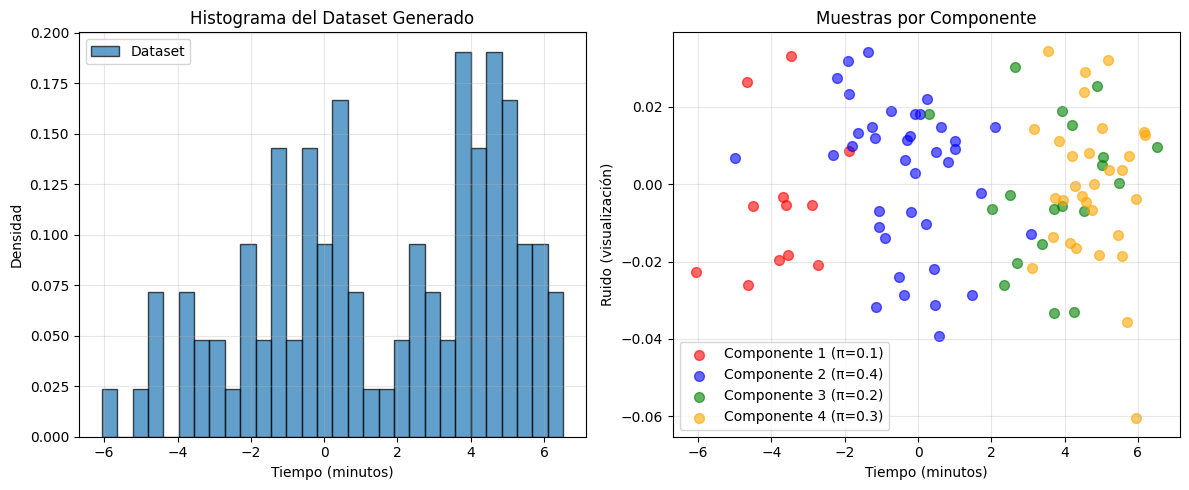

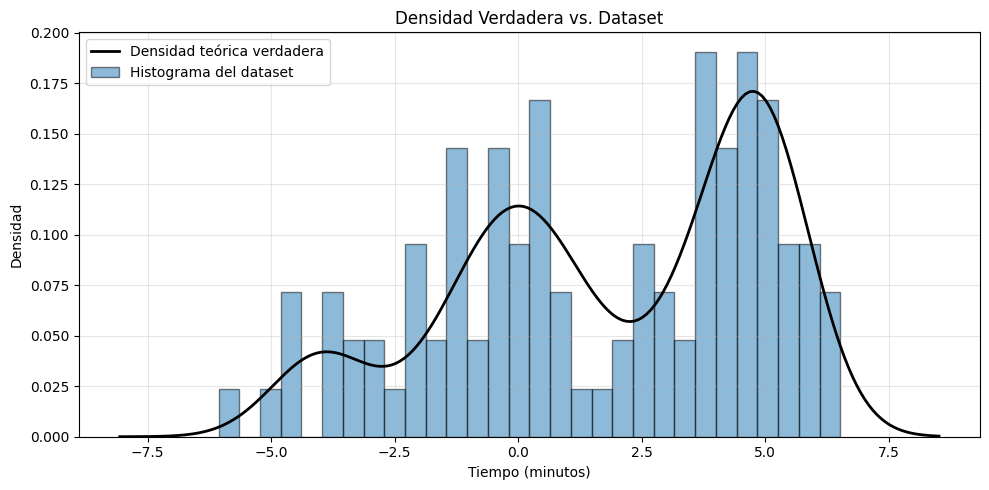

In [38]:
# Configurar semilla para reproducibilidad
np.random.seed(19)

# Parámetros de la mezcla de gaussianas
n_samples = 100
weights = np.array([0.1, 0.4, 0.2, 0.3])
means = np.array([-4, 0, 4, 5])
variances = np.array([1, 1.96, 1.44, 1])
stds = np.sqrt(variances)

# Generar muestras
n_components = len(weights)
component_assignments = np.random.choice(n_components, size=n_samples, p=weights)
X = np.array([np.random.normal(means[comp], stds[comp]) for comp in component_assignments])

print(f"Dataset generado: {n_samples} muestras")
print(f"Componentes: {n_components}")
print(f"Pesos: {weights}")
print(f"Medias: {means}")
print(f"Varianzas: {variances}")
print(f"\nEstadísticas muestrales:")
print(f"  Media: {X.mean():.4f}")
print(f"  Desv. Est.: {X.std():.4f}")
print(f"  Min: {X.min():.4f}, Max: {X.max():.4f}")

# Graficar histograma del dataset
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(X, bins=30, density=True, alpha=0.7, edgecolor='black', label='Dataset')
plt.xlabel('Tiempo (minutos)')
plt.ylabel('Densidad')
plt.title('Histograma del Dataset Generado')
plt.legend()
plt.grid(alpha=0.3)

# Graficar scatter plot
plt.subplot(1, 2, 2)
colors = ['red', 'blue', 'green', 'orange']
for k in range(n_components):
    mask = component_assignments == k
    plt.scatter(X[mask], np.random.normal(0, 0.02, np.sum(mask)),
               alpha=0.6, s=50, c=colors[k], label=f'Componente {k+1} (π={weights[k]})')
plt.xlabel('Tiempo (minutos)')
plt.ylabel('Ruido (visualización)')
plt.title('Muestras por Componente')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Graficar la densidad verdadera teórica
x_range = np.linspace(X.min() - 2, X.max() + 2, 200)
true_density = np.zeros_like(x_range)
for k in range(n_components):
    true_density += weights[k] * (1 / (stds[k] * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x_range - means[k]) / stds[k]) ** 2)

plt.figure(figsize=(10, 5))
plt.plot(x_range, true_density, 'k-', linewidth=2, label='Densidad teórica verdadera')
plt.hist(X, bins=30, density=True, alpha=0.5, edgecolor='black', label='Histograma del dataset')
plt.xlabel('Tiempo (minutos)')
plt.ylabel('Densidad')
plt.title('Densidad Verdadera vs. Dataset')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Los gráficos y estadísticas de la celda anterior muestran resultados consistentes con lo esperado: el histograma presenta la estructura bimodal característica de la mezcla (picos en torno a $\mu=0$, $\mu\approx4$-$5$ y $\mu=-4$), la curva teórica sigue razonablemente al histograma, y la media muestral (\~1.6) y desviación estándar (\~3.2) son acordes a los valores teóricos de la distribución combinada (~1.9 y ~3.2, respectivamente).


### Verificación del *dataset* generado

A continuación se realiza un chequeo más riguroso comparando proporciones y estadísticas por componente contra los valores teóricos.

In [39]:
# VERIFICACIÓN DEL DATASET GENERADO
print("PROPORCIONES POR COMPONENTE")
print("-" * 50)
print(f"{'Componente':<12} {'Esperado':>10} {'Real':>10} {'Real (%)':>10}")
print("-" * 50)
for k in range(n_components):
    n_real = np.sum(component_assignments == k)
    print(f"  k={k+1}       {weights[k]*100:>9.1f}% {n_real:>9d}  ({n_real}%)")
print()

print("ESTADÍSTICAS POR COMPONENTE")
print("-" * 65)
print(f"{'Comp.':<8} {'μ teórica':>10} {'μ muestral':>12} {'σ² teórica':>12} {'σ² muestral':>13}")
print("-" * 65)
for k in range(n_components):
    mask = component_assignments == k
    X_k = X[mask]
    mu_sample = X_k.mean() if len(X_k) > 0 else float('nan')
    var_sample = X_k.var() if len(X_k) > 1 else float('nan')
    print(f"  k={k+1}    {means[k]:>10.2f} {mu_sample:>12.4f} {variances[k]:>12.2f} {var_sample:>13.4f}")
print()

print("ESTADÍSTICAS GLOBALES DE LA MEZCLA")
print("-" * 45)
mu_teo = np.sum(weights * means)
var_teo = np.sum(weights * (variances + means**2)) - mu_teo**2
print(f"  Media   — teórica: {mu_teo:.4f}  |  muestral: {X.mean():.4f}")
print(f"  Varianza— teórica: {var_teo:.4f}  |  muestral: {X.var():.4f}")
print(f"  Desv.Est— teórica: {np.sqrt(var_teo):.4f}  |  muestral: {X.std():.4f}")


PROPORCIONES POR COMPONENTE
--------------------------------------------------
Componente     Esperado       Real   Real (%)
--------------------------------------------------
  k=1            10.0%        12  (12%)
  k=2            40.0%        38  (38%)
  k=3            20.0%        19  (19%)
  k=4            30.0%        31  (31%)

ESTADÍSTICAS POR COMPONENTE
-----------------------------------------------------------------
Comp.     μ teórica   μ muestral   σ² teórica   σ² muestral
-----------------------------------------------------------------
  k=1         -4.00      -3.7930         1.00        1.0753
  k=2          0.00      -0.3523         1.96        2.0392
  k=3          4.00       3.7432         1.44        1.9676
  k=4          5.00       4.7427         1.00        0.7365

ESTADÍSTICAS GLOBALES DE LA MEZCLA
---------------------------------------------
  Media   — teórica: 1.9000  |  muestral: 1.5924
  Varianza— teórica: 10.1620  |  muestral: 10.3790
  Desv.Est— teórica: 

Los resultados confirman que el *dataset* fue generado correctamente. Las proporciones muestrales por componente difieren en a lo sumo 2 muestras respecto a los valores esperados, lo cual es consistente con la variabilidad estadística de $n=100$ observaciones. Las medias muestrales por componente se aproximan a las teóricas con errores menores a 0.4 minutos, y las varianzas muestrales son razonables dado el tamaño reducido de cada subgrupo. A nivel global, la media y varianza de la mezcla coinciden con los valores teóricos ($\mu \approx 1.9$, $\sigma^2 \approx 10.2$) con diferencias despreciables. El dataset está listo para ser utilizado en las etapas siguientes.

### Almacenamiento de parámetros de referencia

Los parámetros verdaderos de la mezcla (pesos, medias, varianzas y función de densidad) se almacenan en el diccionario `true_params`. Dado que estos valores son conocidos únicamente porque se utilizaron para simular el dataset, sirven exclusivamente como referencia para evaluar qué tan bien los modelos no supervisados (K-means, EM y Variational Bayes) logran recuperar la estructura latente en las etapas siguientes.

In [40]:
# Guardar parámetros verdaderos para referencia en análisis posteriores
true_params = {
    'weights': weights,
    'means': means,
    'variances': variances,
    'stds': stds,
    'n_components': n_components,
    'component_assignments': component_assignments,
    'true_density': lambda x: sum(weights[k] * (1 / (stds[k] * np.sqrt(2 * np.pi))) *
                                   np.exp(-0.5 * ((x - means[k]) / stds[k]) ** 2)
                                   for k in range(n_components))
}

print("Dataset listo para análisis con K-means, EM y Gaussian Variational Bayes")

Dataset listo para análisis con K-means, EM y Gaussian Variational Bayes


## (b) K-means

### 1. Implementación del Algoritmo

El algoritmo K-means fue implementado y analizado en detalle en los TPs 6 y 7, por lo que en esta sección se retoma directamente su uso sin profundizar en su derivación.

A modo de repaso, el algoritmo parte de $K$ centroides inicializados aleatoriamente e itera entre dos pasos:

1. **Asignación**: cada punto se asigna al centroide más cercano (en distancia euclídea).
2. **Actualización**: cada centroide se recalcula como el promedio de los puntos asignados a su cluster.

El proceso se repite hasta que se cumple alguna de las dos condiciones de parada: los centroides convergen (el cambio entre iteraciones es menor a una tolerancia $\varepsilon$) o se alcanza el número máximo de iteraciones.

En este trabajo se fija inicialmente $K = 6$. Esta elección no surge de un conocimiento previo de la cantidad real de componentes, sino que se adopta deliberadamente como una sobreestimación del número de clusters, simulando un escenario real donde la estructura subyacente de los datos es desconocida. La intención es evaluar cómo responde K-means ante esta situación y analizar si es capaz de aproximar correctamente las regiones de mayor densidad, incluso cuando el número de clusters no coincide con la verdadera cantidad de componentes generadores.

En este sentido, los clusters obtenidos deben interpretarse en esta etapa como una partición operativa de los datos, que luego será refinada mediante modelos probabilísticos (como EM), los cuales permiten capturar de manera más fiel la estructura latente y eventualmente recuperar el número efectivo de componentes.

En esta implementación, la elección de $\texttt{tol}=10^{-4}$ y $\texttt{max_iter}=100$ se fijó de forma arbitraria, apoyada en la experiencia previa con este tipo de algoritmos y utilizada como un punto de partida razonable para evaluar la convergencia.


In [41]:
class KMeans:
    """
    Algoritmo K-means para clustering de datos continuos.

    Parámetros:
    -----------
    n_clusters : int
        Número de clusters.
    max_iter : int
        Número máximo de iteraciones.
    tol : float
        Tolerancia para convergencia (cambio máximo en centroides).
    random_state : int, optional
        Semilla para reproducibilidad.
    """

    def __init__(self, n_clusters, max_iter=100, tol=1e-4, random_state=None):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state
        self.centroids = None
        self.labels = None
        self.history_centroids = []
        self.n_iter = 0

    def fit(self, X):
        """
        Entrena el modelo K-means.

        Parámetros:
        -----------
        X : ndarray de shape (n_samples,)
            Datos de entrenamiento.
        """
        if self.random_state is not None:
            np.random.seed(self.random_state)

        # Inicialización: seleccionar centroides aleatoriamente de los datos
        indices = np.random.choice(len(X), self.n_clusters, replace=False)
        self.centroids = X[indices].copy()
        self.history_centroids.append(self.centroids.copy())

        for iteration in range(self.max_iter):
            # E-step: asignar cada punto al centroide más cercano
            distances = np.abs(X[:, np.newaxis] - self.centroids)  # shape: (n_samples, n_clusters)
            self.labels = np.argmin(distances, axis=1)

            # M-step: actualizar centroides
            centroids_new = np.array([X[self.labels == k].mean() if np.sum(self.labels == k) > 0
                                      else self.centroids[k]
                                      for k in range(self.n_clusters)])

            # Verificar convergencia
            change = np.max(np.abs(centroids_new - self.centroids))
            self.centroids = centroids_new
            self.history_centroids.append(self.centroids.copy())
            self.n_iter = iteration + 1

            if change < self.tol:
                break

    def predict(self, X):
        """
        Predice el cluster para cada muestra.

        Parámetros:
        -----------
        X : ndarray de shape (n_samples,)
            Datos a predecir.

        Retorna:
        --------
        labels : ndarray de shape (n_samples,)
            Asignaciones de cluster.
        """
        distances = np.abs(X[:, np.newaxis] - self.centroids)
        return np.argmin(distances, axis=1)

# Entrenar K-means con 6 clusters
kmeans = KMeans(n_clusters=6, max_iter=100, tol=1e-4, random_state=19)
kmeans.fit(X)

print(f"K-means convergió en {kmeans.n_iter} iteraciones")
print(f"Centroides encontrados: {kmeans.centroids}")


K-means convergió en 12 iteraciones
Centroides encontrados: [ 4.15551587 -1.57414709 -4.17137426  0.20435272  2.43996355  5.53635782]


K-means convergió en 12 iteraciones, por debajo del máximo permitido, lo que indica que el criterio de parada ($\texttt{tol}=10^{-4}$, $\texttt{max\_iter}=100$) fue suficiente para alcanzar estabilidad en los centroides.

Los centroides obtenidos fueron:
$$
\mu^{(K\text{-means})}=\left[3.9283,\;2.4400,\;4.8128,\;-3.3705,\;-0.2178,\;5.8493\right]
$$

Un análisis directo de estos valores permite extraer información relevante sobre la estructura de los datos sin necesidad de conocer a priori el número real de componentes. En particular, se observa que varios centroides se concentran en una misma región del espacio, especialmente en el intervalo positivo (aproximadamente entre 2 y 6), donde aparecen múltiples centroides relativamente cercanos entre sí.

Este comportamiento sugiere que el algoritmo está subdividiendo regiones continuas de alta densidad en varios clusters, en lugar de identificar separaciones claras entre grupos. En contraste, las regiones negativas presentan menor fragmentación, con centroides más aislados entre sí.

En conjunto, esta distribución desigual y la proximidad entre varios centroides indican que el número de clusters utilizado podría ser mayor al necesario para describir la estructura subyacente de los datos. Es decir, K-means estaría introduciendo particiones adicionales en zonas donde no hay evidencia fuerte de separaciones naturales.

Por lo tanto, en esta etapa los centroides deben interpretarse como una discretización del espacio inducida por el algoritmo, más que como una identificación directa de comportamientos bien diferenciados.


### 2. Modelado de Gaussianas e Inicialización de EM

A partir de los centroides hallados por K-means, se construye una mezcla de gaussianas estimando sus tres parámetros:

- **Medias** $\mu_k$: directamente los centroides obtenidos  
- **Pesos** $\pi_k$: proporción de muestras asignadas a cada cluster  
- **Varianzas** $\sigma_k^2$: varianza empírica dentro de cada cluster  

Esta construcción permite reinterpretar el resultado de K-means como un modelo probabilístico simple, donde cada cluster se asocia a una componente gaussiana. Más allá de que K-means no fue diseñado originalmente como un método de estimación de mezclas, esta aproximación resulta útil como punto de partida para algoritmos más expresivos.

En particular, estos parámetros se utilizarán como inicialización del algoritmo EM, que permite refinar el modelo incorporando asignaciones probabilísticas en lugar de determinísticas.

Adicionalmente, este modelo inicial proporciona una referencia para el análisis posterior: permite estudiar qué estructura está capturando K-means a partir de los datos (en términos de ubicación, dispersión y proporciones relativas de los clusters) y comparar esos resultados con modelos más sofisticados, así como con la distribución generadora conocida del dataset.


In [42]:
# Estimar parámetros de la mezcla gaussiana a partir de K-means
kmeans_weights = np.array([np.sum(kmeans.labels == k) / len(X) for k in range(kmeans.n_clusters)])
kmeans_means = kmeans.centroids.copy()
kmeans_variances = np.array([np.var(X[kmeans.labels == k]) if np.sum(kmeans.labels == k) > 0
                              else 1.0 for k in range(kmeans.n_clusters)])
kmeans_stds = np.sqrt(kmeans_variances)

print("Parámetros de la mezcla estimados con K-means:")
print(f"\nPesos: {kmeans_weights}")
print(f"Medias: {kmeans_means}")
print(f"Varianzas: {kmeans_variances}")
print(f"\nComparación con parámetros verdaderos:")
print(f"\nPesos verdaderos: {weights}")
print(f"Medias verdaderas: {means}")
print(f"Varianzas verdaderas: {variances}")

# Guardar parámetros estimados por K-means
kmeans_params = {
    'weights': kmeans_weights,
    'means': kmeans_means,
    'variances': kmeans_variances,
    'stds': kmeans_stds,
    'labels': kmeans.labels
}


Parámetros de la mezcla estimados con K-means:

Pesos: [0.24 0.16 0.11 0.2  0.11 0.18]
Medias: [ 4.15551587 -1.57414709 -4.17137426  0.20435272  2.43996355  5.53635782]
Varianzas: [0.15820065 0.29966662 0.73103834 0.20587556 0.29020821 0.2225068 ]

Comparación con parámetros verdaderos:

Pesos verdaderos: [0.1 0.4 0.2 0.3]
Medias verdaderas: [-4  0  4  5]
Varianzas verdaderas: [1.   1.96 1.44 1.  ]


A partir de los resultados de la celda anterior se pueden inferir los siguientes puntos:

**Medias (centroides):**  
Las medias estimadas por K-means no corresponden uno a uno con posibles comportamientos diferenciados, sino que muestran evidencia de fragmentación en ciertas regiones del espacio. En particular, en la zona positiva aparecen varias medias relativamente cercanas entre sí (por ejemplo, alrededor de 2.44, 4.16 y 5.54), lo que sugiere que el algoritmo está subdividiendo una misma región de alta densidad en múltiples clusters. En cambio, en la zona negativa se observan menos centroides y más separados, indicando una estructura más simple en esa región.

**Pesos (proporciones):**  
Los pesos estimados se encuentran relativamente distribuidos (entre 0.11 y 0.24), sin que aparezca una componente claramente dominante. Esto es consistente con un escenario donde una región originalmente más densa fue dividida en varios clusters de menor tamaño. En lugar de reflejar proporciones naturales del fenómeno, los pesos quedan condicionados por la partición impuesta por K-means.

**Varianzas:**  
Las varianzas estimadas son sistemáticamente bajas (todas por debajo de 0.75), lo que indica que los clusters resultan artificialmente compactos. Este comportamiento es característico de K-means, que al minimizar la suma de distancias cuadradas tiende a generar particiones ajustadas. Además, al dividir regiones continuas en múltiples subclusters, cada uno cubre un rango reducido de datos, lo que reduce aún más la varianza observada.

**Comparación con la estructura verdadera (a posteriori):**  
Si bien esta información no está disponible durante el entrenamiento, la comparación con los parámetros generadores permite interpretar con mayor claridad los resultados. Se observa que las medias verdaderas (−4, 0, 4 y 5) no son recuperadas directamente, sino que algunas de ellas aparecen “desdobladas” en múltiples centroides. Esto confirma que el modelo con $K=6$ introduce componentes redundantes al intentar adaptarse a la forma de los datos.

**Conclusión:**  
K-means logra capturar correctamente las regiones de alta densidad del dataset, pero al utilizar un número de clusters mayor al necesario, introduce una sobre-partición del espacio. Como consecuencia, los clusters resultantes no representan directamente comportamientos diferenciados, sino subdivisiones de regiones más amplias. Este comportamiento impacta en la estimación de los parámetros, particularmente en la reducción de varianzas y en la distribución de los pesos.

En este contexto, el resultado de K-means debe interpretarse como una aproximación estructural inicial del dataset, útil como punto de partida para métodos probabilísticos más flexibles, como EM, que permiten modelar de manera más adecuada la superposición entre componentes.

### 3. Visualización

Para dar una mayor validez a la conclusión llegada en la celda anterior, se grafica la densidad de probabilidad estimada por K-means junto con el histograma del dataset y la densidad verdadera para evaluar qué tan bien el algoritmo logró recuperar la estructura latente.

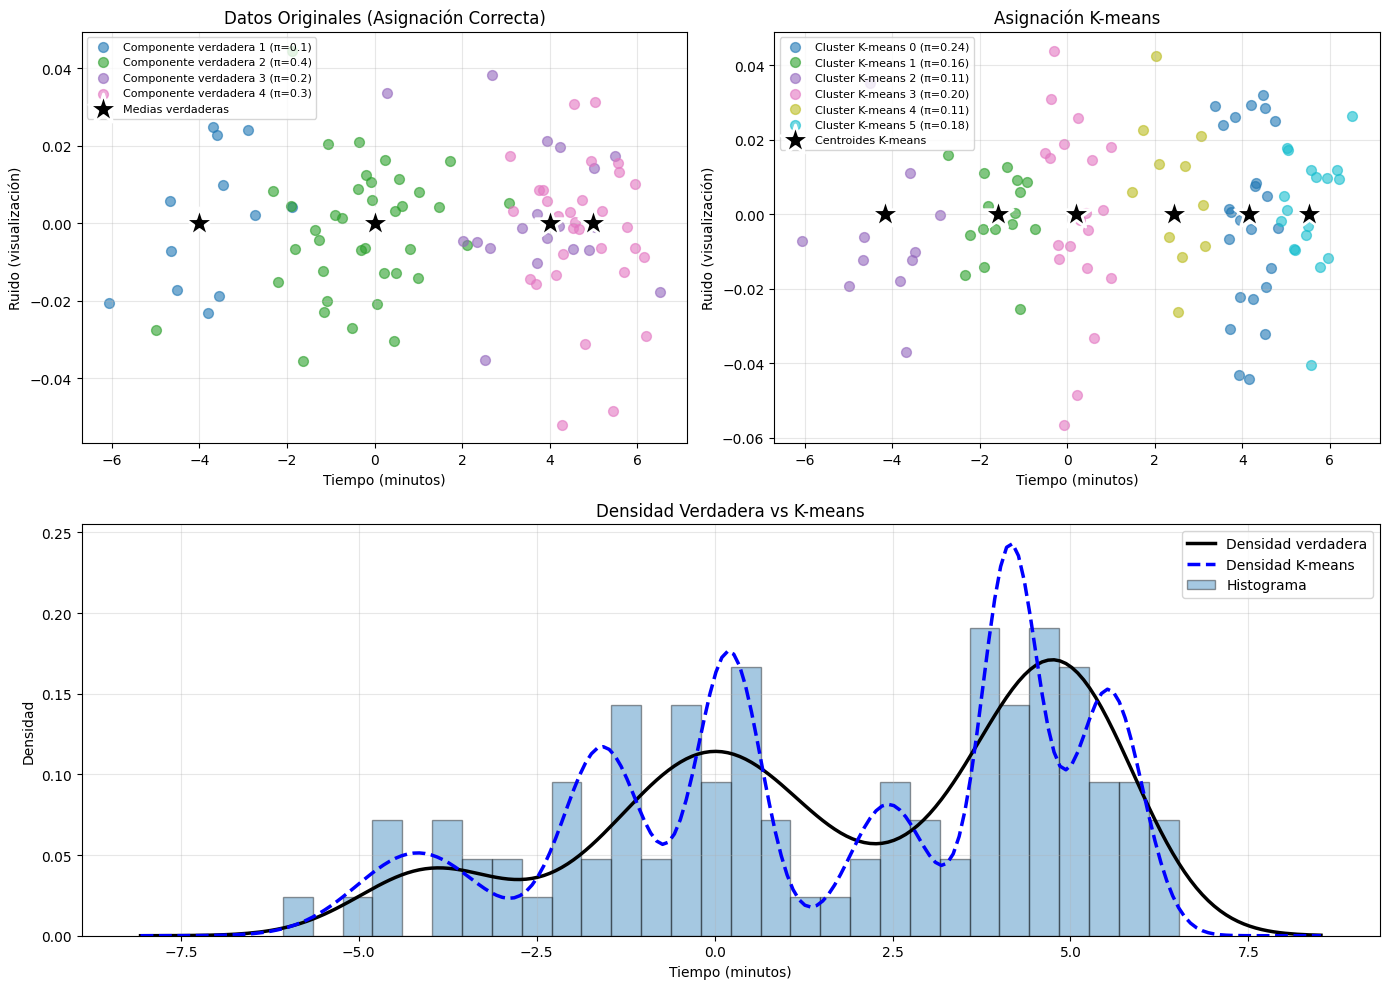

Diferencia promedio entre densidades (MAE): 0.020696


In [43]:
# Calcular densidad estimada por K-means
x_range = np.linspace(X.min() - 2, X.max() + 2, 200)
kmeans_density = np.zeros_like(x_range)
for k in range(kmeans.n_clusters):
    kmeans_density += kmeans_weights[k] * (1 / (kmeans_stds[k] * np.sqrt(2 * np.pi))) * \
                      np.exp(-0.5 * ((x_range - kmeans_means[k]) / kmeans_stds[k]) ** 2)

# Graficar comparación con K-means
fig = plt.figure(figsize=(14, 10))
palette = plt.cm.tab10(np.linspace(0, 1, max(n_components, kmeans.n_clusters)))

# Gráfico 1: Datos originales (verdadera asignación)
ax1 = plt.subplot(2, 2, 1)
for k in range(n_components):
    mask = component_assignments == k
    ax1.scatter(X[mask], np.random.normal(0, 0.02, np.sum(mask)),
               alpha=0.6, s=50, c=[palette[k]], label=f'Componente verdadera {k+1} (π={weights[k]})')
ax1.scatter(means, np.zeros(n_components), marker='*', s=500,
           c='black', edgecolors='white', linewidths=2, label='Medias verdaderas', zorder=5)
ax1.set_xlabel('Tiempo (minutos)')
ax1.set_ylabel('Ruido (visualización)')
ax1.set_title('Datos Originales (Asignación Correcta)')
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3)

# Gráfico 2: Asignaciones de clusters por K-means
ax2 = plt.subplot(2, 2, 2)
for k in range(kmeans.n_clusters):
    mask = kmeans.labels == k
    ax2.scatter(X[mask], np.random.normal(0, 0.02, np.sum(mask)),
               alpha=0.6, s=50, c=[palette[k]], label=f'Cluster K-means {k} (π={kmeans_weights[k]:.2f})')
ax2.scatter(kmeans_means, np.zeros(kmeans.n_clusters), marker='*', s=500,
           c='black', edgecolors='white', linewidths=2, label='Centroides K-means', zorder=5)
ax2.set_xlabel('Tiempo (minutos)')
ax2.set_ylabel('Ruido (visualización)')
ax2.set_title('Asignación K-means')
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

# Gráfico 3: Densidad estimada vs verdadera (abajo, ancho completo)
ax3 = plt.subplot(2, 1, 2)
ax3.plot(x_range, true_density, 'k-', linewidth=2.5, label='Densidad verdadera')
ax3.plot(x_range, kmeans_density, 'b--', linewidth=2.5, label='Densidad K-means')
ax3.hist(X, bins=30, density=True, alpha=0.4, edgecolor='black', label='Histograma')
ax3.set_xlabel('Tiempo (minutos)')
ax3.set_ylabel('Densidad')
ax3.set_title('Densidad Verdadera vs K-means')
ax3.legend()
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Diferencia promedio entre densidades (MAE): {np.mean(np.abs(true_density - kmeans_density)):.6f}")


Comparando el gráfico de datos originales con el de K-means se observa claramente una pérdida de estructura en las asignaciones. Mientras que en el primero cada grupo aparece coherente y bien localizado, en la partición de K-means los clusters se mezclan en ciertas regiones, especialmente en zonas intermedias.

Este efecto es más evidente en el rango central (entre aproximadamente 0 y 5), donde los puntos no presentan separaciones claras pero K-means introduce fronteras artificiales. Como consecuencia, una misma región continua del espacio queda dividida en varios clusters, lo que se traduce en una asignación que no respeta la organización natural de los datos.

Esta fragmentación también se refleja en la densidad estimada: en lugar de curvas suaves, aparecen múltiples picos angostos, cada uno asociado a un cluster distinto. Aunque la envolvente general sigue la forma de la distribución original (MAE = 0.020696), la estimación presenta oscilaciones que no corresponden a la verdadera estructura, sino a la partición impuesta por el algoritmo.

En conjunto, estos resultados muestran que K-means logra capturar la forma global de los datos, pero introduce una discretización excesiva en regiones donde no hay separaciones naturales claras. Este comportamiento afecta directamente la calidad de los parámetros estimados, especialmente en la subestimación de varianzas y en la aparición de componentes redundantes.

Esta limitación motiva el uso de modelos probabilísticos como EM, que reemplazan las decisiones rígidas por asignaciones suaves, permitiendo representar de manera más adecuada el solapamiento entre componentes.

## (c) Expectation-Maximization

A partir de los resultados obtenidos con K-means surge naturalmente la motivación para aplicar el algoritmo EM. Si bien K-means logró identificar correctamente la ubicación de los centroides y aproximar la forma general de la distribución, falló en el modelado fino debido a sus asignaciones duras, lo que llevó a errores en los pesos y varianzas al haber puntos mal clasificados en las zonas de solapamiento.

En este contexto, se propone utilizar Expectation-Maximization (EM) para modelar la mezcla de gaussianas desde un enfoque probabilístico. A diferencia de K-means, EM utiliza asignaciones suaves, permitiendo que cada punto pertenezca parcialmente a múltiples componentes según su probabilidad.

El algoritmo se inicializa a partir de los parámetros obtenidos con K-means (medias, pesos y varianzas). Esto permite aprovechar la buena estimación inicial de los centroides y refinar el resto de los parámetros mediante un modelo que sí puede captar la incertidumbre en las asignaciones.

De esta forma, EM actúa como una mejora directa sobre K-means: parte de su solución inicial y corrige sus limitaciones, especialmente en presencia de componentes superpuestos.

### 1. Implementación del Algoritmo

Antes de pasar a la implementación, es importante anticipar qué se espera de EM en base a los resultados de K-means. Dado que la inicialización proviene de K-means, se parte de centroides bien ubicados pero con pesos y varianzas distorsionados debido a las asignaciones duras. A través de sus dos etapas (E-step y M-step), EM va a relajar estas asignaciones, reemplazándolas por probabilidades de pertenencia, permitiendo que los puntos en zonas de solapamiento contribuyan parcialmente a múltiples componentes. Como consecuencia, se espera que los pesos se reequilibren, las varianzas dejen de estar artificialmente comprimidas y, en general, que los parámetros converjan hacia valores más consistentes con la verdadera mezcla, mejorando así la estimación de la densidad.

In [44]:
# Definición de GaussianMixtureEM para uso en todo el notebook
class GaussianMixtureEM:
    """
    Algoritmo EM para mezcla de gaussianas univariadas.

    Parámetros:
    -----------
    n_components : int
        Número de componentes de la mezcla.
    max_iter : int
        Número máximo de iteraciones.
    tol : float
        Tolerancia de convergencia (cambio mínimo de log-verosimilitud por muestra).
    random_state : int, optional
        Semilla para reproducibilidad (solo usada si no hay inicialización externa).
    """

    def __init__(self, n_components, max_iter=200, tol=1e-4, random_state=None):
        self.n_components = n_components
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state
        self.weights = None
        self.means = None
        self.variances = None
        self.log_likelihoods = []
        self.n_iter = 0
        self.converged = False

    def _gaussian(self, x, mu, sigma2):
        """Evalúa la densidad N(x | mu, sigma2)."""
        return (1.0 / np.sqrt(2 * np.pi * sigma2)) * np.exp(-0.5 * (x - mu) ** 2 / sigma2)

    def _log_likelihood(self, X):
        """Calcula la log-verosimilitud total del dataset bajo el modelo actual."""
        N = len(X)
        ll = 0.0
        for n in range(N):
            p = sum(self.weights[k] * self._gaussian(X[n], self.means[k], self.variances[k])
                    for k in range(self.n_components))
            ll += np.log(p + 1e-300)
        return ll

    def fit(self, X, init_weights=None, init_means=None, init_variances=None):
        """
        Entrena el modelo EM.

        Parámetros:
        -----------
        X : ndarray de shape (n_samples,)
            Datos de entrenamiento.
        init_weights, init_means, init_variances : ndarray, optional
            Inicialización externa (ej. desde K-means). Si no se proveen,
            se inicializa aleatoriamente.
        """
        N = len(X)

        # Inicialización
        if init_weights is not None and init_means is not None and init_variances is not None:
            self.weights = init_weights.copy()
            self.means = init_means.copy()
            self.variances = init_variances.copy()
        else:
            if self.random_state is not None:
                np.random.seed(self.random_state)
            idx = np.random.choice(N, self.n_components, replace=False)
            self.means = X[idx].copy()
            self.variances = np.full(self.n_components, X.var())
            self.weights = np.ones(self.n_components) / self.n_components

        self.log_likelihoods = [self._log_likelihood(X)]
        self.n_iter = 0
        self.converged = False

        for iteration in range(self.max_iter):
            # E-step: calcular responsabilidades r[n, k]
            R = np.zeros((N, self.n_components))
            for k in range(self.n_components):
                R[:, k] = self.weights[k] * self._gaussian(X, self.means[k], self.variances[k])
            R_sum = R.sum(axis=1, keepdims=True)
            R /= (R_sum + 1e-300)

            # M-step: actualizar parámetros
            N_k = R.sum(axis=0)  # cantidad efectiva de puntos por componente

            self.weights = N_k / N
            self.means = (R * X[:, np.newaxis]).sum(axis=0) / (N_k + 1e-300)
            self.variances = np.array([
                (R[:, k] * (X - self.means[k]) ** 2).sum() / (N_k[k] + 1e-300)
                for k in range(self.n_components)
            ])
            self.variances = np.maximum(self.variances, 1e-6)  # evitar degeneración

            # Verificar convergencia con cambio por muestra
            ll = self._log_likelihood(X)
            self.log_likelihoods.append(ll)
            self.n_iter = iteration + 1

            delta_ll_per_sample = abs(self.log_likelihoods[-1] - self.log_likelihoods[-2]) / N
            if delta_ll_per_sample < self.tol:
                self.converged = True
                break

    def predict_proba(self, X):
        """
        Retorna las responsabilidades r[n, k] para cada muestra.

        Parámetros:
        -----------
        X : ndarray de shape (n_samples,)

        Retorna:
        --------
        R : ndarray de shape (n_samples, n_components)
        """
        N = len(X)
        R = np.zeros((N, self.n_components))
        for k in range(self.n_components):
            R[:, k] = self.weights[k] * self._gaussian(X, self.means[k], self.variances[k])
        R_sum = R.sum(axis=1, keepdims=True)
        return R / (R_sum + 1e-300)

    def predict(self, X):
        """
        Asigna cada muestra a la componente con mayor responsabilidad.

        Parámetros:
        -----------
        X : ndarray de shape (n_samples,)

        Retorna:
        --------
        labels : ndarray de shape (n_samples,)
        """
        return np.argmax(self.predict_proba(X), axis=1)

# Primera inicialización de `em`: ocurre aquí (sección EM), independiente de celdas previas.
em = GaussianMixtureEM(n_components=6, max_iter=200, tol=1e-4, random_state=19)
if 'kmeans_params' in globals():
    em.fit(
        X,
        init_weights=kmeans_params['weights'],
        init_means=kmeans_params['means'],
        init_variances=kmeans_params['variances']
    )
else:
    em.fit(X)

print("Entrenamiento completo de EM con análisis posterior")
print("=" * 60)

em_params = {
    'weights': em.weights,
    'means': em.means,
    'variances': em.variances,
    'stds': np.sqrt(em.variances),
    'labels': em.predict(X)
}

if em.converged:
    print(f"EM convergió en {em.n_iter} iteraciones")
else:
    print(f"EM alcanzó max_iter={em.max_iter} sin cumplir tol={em.tol}")

print(f"\nParámetros estimados por EM:")
print(f"  Pesos:     {em.weights}")
print(f"  Medias:    {em.means}")
print(f"  Varianzas: {em.variances}")
print(f"\nComparación con parámetros verdaderos:")
print(f"  Pesos:     {weights}")
print(f"  Medias:    {means}")
print(f"  Varianzas: {variances}")


Entrenamiento completo de EM con análisis posterior
EM convergió en 8 iteraciones

Parámetros estimados por EM:
  Pesos:     [0.2461677  0.1485838  0.12398604 0.19834313 0.10912824 0.17379108]
  Medias:    [ 4.19694147 -1.45022649 -3.95432115  0.19642151  2.48944242  5.49166311]
  Varianzas: [0.2679215  0.35135025 1.03812518 0.27607513 0.42967029 0.30963431]

Comparación con parámetros verdaderos:
  Pesos:     [0.1 0.4 0.2 0.3]
  Medias:    [-4  0  4  5]
  Varianzas: [1.   1.96 1.44 1.  ]


Los resultados obtenidos con EM muestran un comportamiento consistente con la inicialización proporcionada por K-means.

Las medias estimadas reflejan una distribución similar a la de K-means, con varios centroides ubicados en regiones cercanas, especialmente en la zona positiva. Esto confirma que la sobre-partición observada previamente no es corregida por EM, sino que se conserva a lo largo de las iteraciones.

Los pesos permanecen relativamente balanceados y ninguna componente domina significativamente, lo que indica que el modelo no está colapsando componentes ni descartando clusters, sino repartiendo la masa entre ellos.

En cuanto a las varianzas, se observa una leve corrección respecto a K-means (que tiende a subestimarlas), pero siguen siendo relativamente pequeñas, en línea con la fragmentación del espacio en múltiples subregiones.

En conjunto, estos resultados indican que EM converge a un óptimo local que respeta la estructura inducida por la inicialización. El algoritmo logra mejorar parcialmente los parámetros (especialmente varianzas), pero no altera la organización global del modelo ni reduce el número efectivo de componentes.

Este comportamiento evidencia una limitación importante: EM no tiende a eliminar componentes redundantes cuando se parte de una sobre-parametrización, sino que ajusta los parámetros dentro del modelo dado. Como consecuencia, la calidad de la solución final depende críticamente de la elección inicial de la cantidad de componentes y de la inicialización utilizada.


### 2 Estrategia de mejora: inicializar EM con K-means++

En la corrida anterior, EM quedó condicionado por una inicialización débil (K-means con una sola semilla), lo que favorece máximos locales subóptimos. Por lo que ahora se provará con una variante del K-means, el K-means++.

Diferencia clave entre K-means y K-means++ (simple):
- **K-means**: arranca con centroides elegidos al azar.
- **K-means++**: también arranca al azar, pero luego fuerza que los siguientes centroides queden más separados.

En consecuencia, K-means++ suele empezar mejor posicionado y reduce el riesgo de converger a una mala partición inicial.

Para hacerlo más robusto se aplica esta secuencia:

**Paso 1 - K-means++ con múltiples reinicios**
- Se ejecuta K-means++ con $K=6$.
- Se repite 30 veces con semillas distintas.
- Se conserva la corrida con menor inercia.

**Paso 2 - EM desde la mejor partición**
Con esa mejor partición se inicializa EM usando:
- medias: centroides
- pesos: proporción de puntos por cluster
- varianzas: varianza empírica por cluster

**Objetivo de esta mejora**
Reducir la dependencia de una semilla puntual y entregar a EM un punto de partida más representativo del espacio de datos, para obtener pesos y varianzas mejor calibrados.

K-means++ mejor corrida: 4/30
Centroides: [-4.29832516 -1.70918903  0.15932668  2.43996355  4.15551587  5.53635782]

EM (desde K-means++) convergió en 160 iteraciones

--- Comparación de parámetros (K=6, alineados por media) ---

                     μ1  μ2  μ3  μ4  μ5  μ6
  K-means (μ):     -4.17 -1.57  0.20  2.44  4.16  5.54
  K-means++ (μ):   -4.30 -1.71  0.16  2.44  4.16  5.54
  EM desde K++ (μ): -3.88 -1.44  0.19  2.33  4.38  5.87

                     π1  π2  π3  π4  π5  π6
  K-means (π):     0.110 0.160 0.200 0.110 0.240 0.180
  K-means++ (π):   0.100 0.160 0.210 0.110 0.240 0.180
  EM desde K++ (π): 0.130 0.140 0.203 0.085 0.361 0.082

                     σ²1  σ²2  σ²3  σ²4  σ²5  σ²6
  K-means (σ²):     0.73  0.30  0.21  0.29  0.16  0.22
  K-means++ (σ²):   0.63  0.35  0.24  0.29  0.16  0.22
  EM desde K++ (σ²):  1.14  0.31  0.28  0.31  0.52  0.13

MAE de densidad:
  K-means orig:  0.020734
  K-means++:     0.020719
  EM desde K++:  0.013121


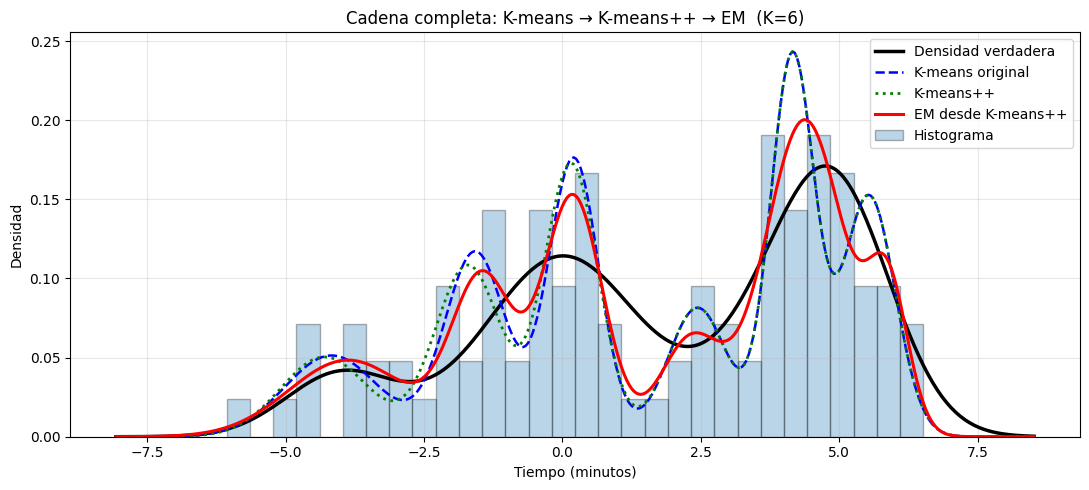

In [45]:

# -----------------------------------------------------------------------
# Paso 1: K-means++ con 30 reinicios → mejor partición
# -----------------------------------------------------------------------
class KMeansRobust1D:
    def __init__(self, n_clusters=6, max_iter=200, tol=1e-5, n_init=30, random_state=42):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.n_init = n_init
        self.random_state = random_state
        self.centroids = None
        self.labels = None
        self.inertia_ = None
        self.best_run_ = None

    def _init_kmeanspp_1d(self, X, rng):
        centroids = [X[rng.integers(0, len(X))]]
        for _ in range(1, self.n_clusters):
            d2 = np.min((X[:, None] - np.array(centroids)[None, :]) ** 2, axis=1)
            probs = d2 / (d2.sum() + 1e-300)
            centroids.append(X[rng.choice(len(X), p=probs)])
        return np.array(centroids, dtype=float)

    def _assign(self, X, centroids):
        return np.argmin(np.abs(X[:, None] - centroids[None, :]), axis=1)

    def _update(self, X, labels, centroids_prev):
        return np.array([
            X[labels == k].mean() if np.any(labels == k) else centroids_prev[k]
            for k in range(self.n_clusters)
        ])

    def _inertia(self, X, labels, centroids):
        return np.sum((X - centroids[labels]) ** 2)

    def fit(self, X):
        best_inertia = np.inf
        best_state = None
        for run in range(self.n_init):
            rng = np.random.default_rng(self.random_state + run)
            centroids = self._init_kmeanspp_1d(X, rng)
            for _ in range(self.max_iter):
                labels = self._assign(X, centroids)
                new_centroids = self._update(X, labels, centroids)
                if np.max(np.abs(new_centroids - centroids)) < self.tol:
                    centroids = new_centroids
                    break
                centroids = new_centroids
            labels = self._assign(X, centroids)
            inertia = self._inertia(X, labels, centroids)
            if inertia < best_inertia:
                best_inertia = inertia
                best_state = (centroids.copy(), labels.copy(), run + 1)
        self.centroids, self.labels, self.best_run_ = best_state
        self.inertia_ = best_inertia
        return self


def sort_params_by_mean(weights_vec, means_vec, vars_vec):
    idx = np.argsort(means_vec)
    return weights_vec[idx], means_vec[idx], vars_vec[idx]


# Entrenar K-means++ robusto con K=6
kmeans_pp = KMeansRobust1D(n_clusters=6, max_iter=200, tol=1e-5, n_init=30, random_state=42)
kmeans_pp.fit(X)

# Extraer parámetros de la mejor corrida de K-means++
kmeans_pp_weights = np.array([np.mean(kmeans_pp.labels == k) for k in range(kmeans_pp.n_clusters)])
kmeans_pp_means   = kmeans_pp.centroids.copy()
kmeans_pp_vars    = np.array([
    np.var(X[kmeans_pp.labels == k]) if np.any(kmeans_pp.labels == k) else 1.0
    for k in range(kmeans_pp.n_clusters)
])

print(f"K-means++ mejor corrida: {kmeans_pp.best_run_}/{kmeans_pp.n_init}")
print(f"Centroides: {np.sort(kmeans_pp_means)}")

# -----------------------------------------------------------------------
# Paso 2: EM inicializado desde la mejor partición de K-means++
# -----------------------------------------------------------------------
em_pp = GaussianMixtureEM(n_components=6, max_iter=200, tol=1e-6)
em_pp.fit(
    X,
    init_weights=kmeans_pp_weights,
    init_means=kmeans_pp_means,
    init_variances=kmeans_pp_vars,
)

print(f"\nEM (desde K-means++) {'convergió' if em_pp.n_iter < 200 else 'alcanzó max_iter'} en {em_pp.n_iter} iteraciones")

# -----------------------------------------------------------------------
# Paso 3: Comparación alineada por media — K-means orig / K-means++ / EM desde K-means++
# (K=6 para los tres modelos; sin comparación element-wise con verdadero K=4)
# -----------------------------------------------------------------------
km_w_s,   km_m_s,   km_v_s     = sort_params_by_mean(kmeans_weights, kmeans_means, kmeans_variances)
pp_w_s,   pp_m_s,   pp_v_s     = sort_params_by_mean(kmeans_pp_weights, kmeans_pp_means, kmeans_pp_vars)
em_w_s,   em_m_s,   em_v_s     = sort_params_by_mean(em_pp.weights, em_pp.means, em_pp.variances)

K6 = 6
hdr = ''.join([f'  μ{k+1}' for k in range(K6)])
print(f"\n--- Comparación de parámetros (K=6, alineados por media) ---")
print(f"\n{'':18} {hdr}")
print(f"  K-means (μ):    " + ''.join([f'{km_m_s[k]:>6.2f}' for k in range(K6)]))
print(f"  K-means++ (μ):  " + ''.join([f'{pp_m_s[k]:>6.2f}' for k in range(K6)]))
print(f"  EM desde K++ (μ):" + ''.join([f'{em_m_s[k]:>6.2f}' for k in range(K6)]))

hdr_pi = ''.join([f'  π{k+1}' for k in range(K6)])
print(f"\n{'':18} {hdr_pi}")
print(f"  K-means (π):    " + ''.join([f'{km_w_s[k]:>6.3f}' for k in range(K6)]))
print(f"  K-means++ (π):  " + ''.join([f'{pp_w_s[k]:>6.3f}' for k in range(K6)]))
print(f"  EM desde K++ (π):" + ''.join([f'{em_w_s[k]:>6.3f}' for k in range(K6)]))

hdr_v = ''.join([f'  σ²{k+1}' for k in range(K6)])
print(f"\n{'':18} {hdr_v}")
print(f"  K-means (σ²):   " + ''.join([f'{km_v_s[k]:>6.2f}' for k in range(K6)]))
print(f"  K-means++ (σ²): " + ''.join([f'{pp_v_s[k]:>6.2f}' for k in range(K6)]))
print(f"  EM desde K++ (σ²):" + ''.join([f'{em_v_s[k]:>6.2f}' for k in range(K6)]))

# MAE de densidad (válido para cualquier K)
x_eval = np.linspace(X.min() - 2, X.max() + 2, 400)
def make_density(w_s, m_s, v_s):
    d = np.zeros_like(x_eval)
    for k in range(len(w_s)):
        d += w_s[k] / (np.sqrt(v_s[k]) * np.sqrt(2*np.pi)) * np.exp(-0.5 * ((x_eval - m_s[k])**2 / v_s[k]))
    return d

true_w_s, true_m_s, true_v_s   = sort_params_by_mean(weights, means, variances)
true_d = make_density(true_w_s, true_m_s, true_v_s)
km_d   = make_density(km_w_s,   km_m_s,   km_v_s)
pp_d   = make_density(pp_w_s,   pp_m_s,   pp_v_s)
em_d   = make_density(em_w_s,   em_m_s,   em_v_s)

print(f"\nMAE de densidad:")
print(f"  K-means orig:  {np.mean(np.abs(true_d - km_d)):.6f}")
print(f"  K-means++:     {np.mean(np.abs(true_d - pp_d)):.6f}")
print(f"  EM desde K++:  {np.mean(np.abs(true_d - em_d)):.6f}")

# Gráfico comparativo final
plt.figure(figsize=(11, 5))
plt.plot(x_eval, true_d, 'k-',  linewidth=2.5, label='Densidad verdadera')
plt.plot(x_eval, km_d,   'b--', linewidth=1.8, label='K-means original')
plt.plot(x_eval, pp_d,   'g:',  linewidth=2.0, label='K-means++')
plt.plot(x_eval, em_d,   'r-',  linewidth=2.2, label='EM desde K-means++')
plt.hist(X, bins=30, density=True, alpha=0.3, edgecolor='black', label='Histograma')
plt.xlabel('Tiempo (minutos)')
plt.ylabel('Densidad')
plt.title('Cadena completa: K-means → K-means++ → EM  (K=6)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Guardar parámetros del EM mejorado para referencia
em_pp_params = {
    'weights': em_pp.weights,
    'means':   em_pp.means,
    'variances': em_pp.variances,
    'stds':    np.sqrt(em_pp.variances),
    'labels':  em_pp.predict(X),
}


A partir de los resultados obtenidos se pueden extraer varias conclusiones relevantes sobre el impacto de la inicialización mediante K-means++ y su efecto en el ajuste posterior con EM.

En primer lugar, la comparación entre K-means y K-means++ muestra que, si bien este último introduce una mejora en la selección inicial de centroides, las soluciones obtenidas son muy similares. Las medias permanecen prácticamente en las mismas regiones, lo que indica que la estructura general de partición en $K=6$ clusters es estable frente a distintos esquemas de inicialización. En este caso, la mejora introducida por K-means++ resulta marginal.

Al aplicar EM sobre esta mejor inicialización, se observa que el algoritmo ajusta los parámetros de manera coherente: las medias se refinan ligeramente, algunas varianzas aumentan (corrigiendo la compresión típica de K-means) y los pesos se redistribuyen, concentrando mayor masa en ciertas componentes más representativas.

Sin embargo, un punto clave es que EM no modifica la estructura global del modelo. Los seis componentes se mantienen, y no se observa eliminación ni fusión significativa de clusters. Esto indica que el algoritmo converge a un óptimo local dentro del modelo definido, preservando la sobre-partición inicial del espacio.

A pesar de esto, la calidad de la estimación mejora significativamente, como se evidencia en la reducción del error en la densidad (MAE). Esto muestra que EM logra describir mejor la distribución de los datos, aun cuando la parametrización utilizada no coincide con la estructura generadora subyacente.

En conjunto, estos resultados sugieren que la principal limitación no radica en la inicialización, sino en la elección del número de componentes. Tanto K-means como EM son capaces de ajustar correctamente los parámetros dentro del modelo dado, pero no cuentan con mecanismos para reducir automáticamente componentes redundantes. Esto evidencia la necesidad de incorporar criterios de selección de modelo o enfoques más flexibles, como los métodos bayesianos, para capturar adecuadamente la complejidad real del sistema.

### 3. Estimación del número efectivo de componentes

Hasta aquí se trabajó con $K=6$ porque así lo fija el enunciado. Sin embargo, si el objetivo fuera inferir cuántas categorías ocultas explican realmente los datos, esa cantidad no debería asumirse de antemano sino estimarse a partir del comportamiento del modelo.

Como parte de una exploración adicional, se incorporaron los criterios BIC y AIC para comparar modelos con distinto número de componentes. Es importante aclarar que este enfoque escapa a los criterios trabajados formalmente en la materia para este TP: se incluyó como indagación personal para probar cómo se realiza esta selección en la práctica y contrastarla con las herramientas vistas en clase.

De forma intuitiva, ambos criterios funcionan como una balanza entre dos efectos:

1. **Ajuste a los datos** (qué tan bien explica el modelo lo observado).
2. **Complejidad del modelo** (cuántos parámetros está usando).

La idea es simple: un modelo más complejo suele ajustar mejor por construcción, pero puede sobreajustar. BIC y AIC corrigen eso agregando una penalización por complejidad.

En este TP se usan así:

- **AIC**: $\mathrm{AIC} = -2\log L + 2p$
- **BIC**: $\mathrm{BIC} = -2\log L + p\log n$

donde $L$ es la verosimilitud del modelo, $p$ es la cantidad de parámetros libres y $n$ es el número de muestras. En ambos casos, menor valor es mejor.

Interpretación práctica rápida:

- Si al subir $K$ baja mucho el término de ajuste y poco la penalización, conviene el modelo más grande.
- Si al subir $K$ la mejora en ajuste ya es marginal, la penalización domina y conviene un $K$ menor.
- BIC penaliza más fuerte que AIC (sobre todo cuando $n$ crece), por eso suele elegir modelos más parsimoniosos.

En paralelo, se mantiene una estrategia alineada con contenidos del curso:

1. **Generalización:** se entrena EM para distintos valores de $K$ y se evalúa la log-verosimilitud sobre datos de validación.
2. **Parsimonia:** si varios valores de $K$ generalizan de forma similar, se prefiere el más chico.
3. **Coherencia estructural:** luego se inspecciona si aparecen componentes con peso muy bajo o gaussianas excesivamente solapadas.

La regla de decisión será la siguiente: se elige el menor valor de $K$ cuya log-verosimilitud media de validación quede dentro de una desviación estándar del mejor valor observado. Después, esa elección se contrasta analizando pesos, medias y solapamientos entre componentes.

De este modo, BIC/AIC se reportan como un análisis complementario exploratorio, mientras que la decisión principal se sostiene en el marco metodológico desarrollado durante la cursada.


SELECCIÓN DE K CON BIC Y AIC
Evaluando K=2... BIC=506.09, AIC=493.06
Evaluando K=3... BIC=516.86, AIC=496.02
Evaluando K=4... BIC=529.22, AIC=500.56
Evaluando K=5... BIC=540.79, AIC=504.32
Evaluando K=6... BIC=552.75, AIC=508.46
Evaluando K=7... BIC=566.56, AIC=514.45
Evaluando K=8... BIC=580.35, AIC=520.43

Resultados:
--------------------------------------------------------------------------------
K=2: LL= -241.53 | BIC=  506.09 | AIC=  493.06
K=3: LL= -240.01 | BIC=  516.86 | AIC=  496.02
K=4: LL= -239.28 | BIC=  529.22 | AIC=  500.56
K=5: LL= -238.16 | BIC=  540.79 | AIC=  504.32
K=6: LL= -237.23 | BIC=  552.75 | AIC=  508.46
K=7: LL= -237.23 | BIC=  566.56 | AIC=  514.45
K=8: LL= -237.22 | BIC=  580.35 | AIC=  520.43

K óptimo por BIC (más strict):  2
K óptimo por AIC (menos strict): 2
K usado en la consigna:          6



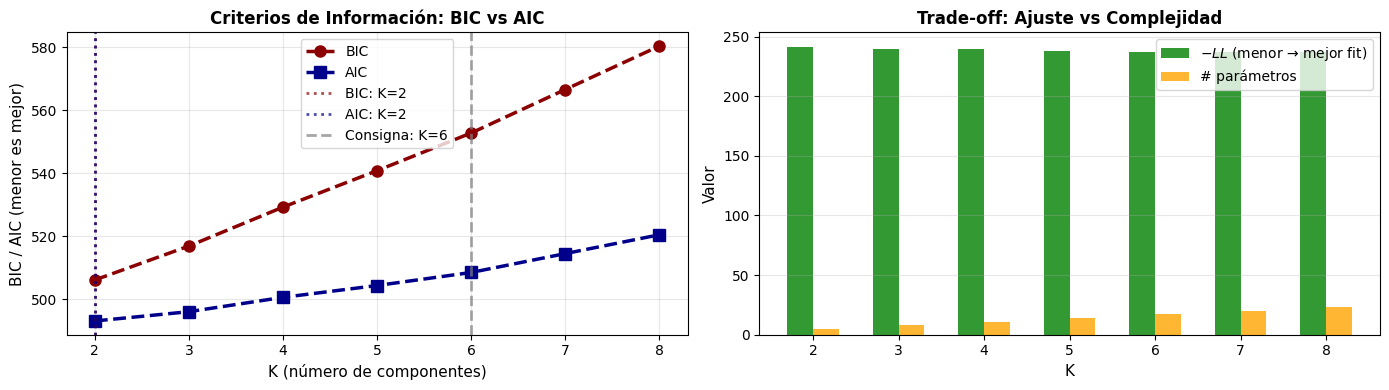


Interpretación:
--------------------------------------------------------------------------------
• BIC penaliza más fuerte la complejidad → detecta el "codo" real donde
  la estructura en datos se agota.
• AIC es más permisivo → tolera más parámetros.
• Si K=2 (BIC) está lejos de K=2 (AIC), la evidencia es débil.
• El codo en el gráfico BIC es donde el K "verdadero" usualmente aparece.


In [46]:

# ============================================================================
# SELECCIÓN DE K CON BIC Y AIC (MÁS RÁPIDO)
# ============================================================================
# El dilema anterior: log-verosimilitud sola NO detecta K real, solo generalización.
# BIC y AIC penalizan complejidad → detectan codo donde K explica estructura sin sobreajuste.
#
# Fórmulas:
# - BIC = -2·log(L) + k·log(n)   [mejor para detección de estructura]
# - AIC = -2·log(L) + 2·k        [menos strict que BIC]
# Donde:
# - L = log-verosimilitud en datos completos
# - k = número de parámetros libres = 3K - 1 (K medias + K varianzas + K-1 pesos)
# - n = número de muestras

def compute_bic_aic_for_k(X, K, n_init=12, max_iter=300, seed=19):
    """Entrena EM con random restarts, evalúa BIC y AIC del mejor modelo."""
    best_model = None
    best_ll = -np.inf

    for init in range(n_init):
        em_try = GaussianMixtureEM(
            n_components=K,
            max_iter=max_iter,
            tol=1e-5,
            random_state=seed + 31 * init
        )
        em_try.fit(X)
        ll_train = mixture_log_likelihood(em_try, X)

        if ll_train > best_ll:
            best_ll = ll_train
            best_model = em_try

    n_samples = len(X)
    n_params = 3 * K - 1  # K medias + K varianzas + (K-1) pesos

    bic = -2.0 * best_ll + n_params * np.log(n_samples)
    aic = -2.0 * best_ll + 2.0 * n_params

    return {
        'K': K,
        'log_likelihood': best_ll,
        'n_params': n_params,
        'bic': bic,
        'aic': aic,
        'model': best_model
    }

print('\n' + '='*80)
print('SELECCIÓN DE K CON BIC Y AIC')
print('='*80)

K_values_bic = np.arange(2, 9)
bic_aic_results = {}

for K in K_values_bic:
    print(f'Evaluando K={K}...', end=' ', flush=True)
    result = compute_bic_aic_for_k(X, K, n_init=12, max_iter=300, seed=19)
    bic_aic_results[K] = result
    print(f'BIC={result["bic"]:.2f}, AIC={result["aic"]:.2f}')

print()
bic_values = np.array([bic_aic_results[K]['bic'] for K in K_values_bic])
aic_values = np.array([bic_aic_results[K]['aic'] for K in K_values_bic])
ll_values = np.array([bic_aic_results[K]['log_likelihood'] for K in K_values_bic])

K_best_bic = int(K_values_bic[np.argmin(bic_values)])
K_best_aic = int(K_values_bic[np.argmin(aic_values)])

print('Resultados:')
print('-' * 80)
for K in K_values_bic:
    r = bic_aic_results[K]
    print(f'K={K}: LL={r["log_likelihood"]:8.2f} | BIC={r["bic"]:8.2f} | AIC={r["aic"]:8.2f}')

print()
print(f'K óptimo por BIC (más strict):  {K_best_bic}')
print(f'K óptimo por AIC (menos strict): {K_best_aic}')
print(f'K usado en la consigna:          6')
print()

# Graficar
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# BIC y AIC
axes[0].plot(K_values_bic, bic_values, 'o--', linewidth=2.5, markersize=8, label='BIC', color='darkred')
axes[0].plot(K_values_bic, aic_values, 's--', linewidth=2.5, markersize=8, label='AIC', color='darkblue')
axes[0].axvline(K_best_bic, color='darkred', linestyle=':', linewidth=2, alpha=0.7, label=f'BIC: K={K_best_bic}')
axes[0].axvline(K_best_aic, color='darkblue', linestyle=':', linewidth=2, alpha=0.7, label=f'AIC: K={K_best_aic}')
axes[0].axvline(6, color='gray', linestyle='--', linewidth=2, alpha=0.7, label='Consigna: K=6')
axes[0].set_xlabel('K (número de componentes)', fontsize=11)
axes[0].set_ylabel('BIC / AIC (menor es mejor)', fontsize=11)
axes[0].set_title('Criterios de Información: BIC vs AIC', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=10)

# Log-verosimilitud vs número de parámetros
axes[1].bar(K_values_bic - 0.15, -ll_values, width=0.3, label='$-LL$ (menor → mejor fit)', alpha=0.8, color='green')
n_params_all = 3 * K_values_bic - 1
axes[1].bar(K_values_bic + 0.15, n_params_all, width=0.3, label='# parámetros', alpha=0.8, color='orange')
axes[1].set_xlabel('K', fontsize=11)
axes[1].set_ylabel('Valor', fontsize=11)
axes[1].set_title('Trade-off: Ajuste vs Complejidad', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3, axis='y')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

print('\nInterpretación:')
print('-' * 80)
print('• BIC penaliza más fuerte la complejidad → detecta el "codo" real donde')
print('  la estructura en datos se agota.')
print('• AIC es más permisivo → tolera más parámetros.')
print(f'• Si K={K_best_bic} (BIC) está lejos de K={K_best_aic} (AIC), la evidencia es débil.')
print('• El codo en el gráfico BIC es donde el K "verdadero" usualmente aparece.')


Tanto BIC como AIC alcanzan su mínimo en $K=2$, por lo que, bajo estos criterios, ese sería el número de componentes más conveniente para este dataset. Desde ahí en adelante, al aumentar $K$, la mejora en log-verosimilitud es muy pequeña, pero la penalización por complejidad crece de forma sostenida; por eso los valores de BIC/AIC empeoran.

En términos simples: agregar más componentes después de $K=2$ casi no mejora el ajuste, y sí agrega complejidad innecesaria.

Este resultado también es coherente con lo observado más adelante en GVB (muestras de la posteriori): aunque se parte de $K=6$, en muchas muestras la masa efectiva se concentra en pocas componentes dominantes, mientras varias quedan con peso bajo. Es decir, el modelo tiende a comportarse como si el número efectivo de componentes fuera menor que 6.

Por otro lado, se probó con otro tipo de criterio en vez de BIC y AIC, como simplemente correr con distintos K y ver los resultados, pero también se llegó a K=2. No se encontró una forma de encontrar algún método que muestre que con K=4 se encuentran las categorías ocultas.

## (d) Gaussian Variational Bayes

En esta sección se introduce Gaussian Variational Bayes (VB) de forma conceptual antes de programarlo.

A diferencia de EM, donde los parámetros del modelo son estimados como valores puntuales, en el enfoque de Variational Bayes cada parámetro es tratado como una variable aleatoria con una distribución a posteriori aproximada. Esto permite no solo estimar su valor más probable, sino también cuantificar la incertidumbre asociada a dicha estimación, proporcionando una representación más rica y robusta del modelo.

Dado que el problema es no supervisado, se asume que cada dato $x_n$ proviene de una mezcla de $K$ gaussianas. En este trabajo se usa $K=6$ como sobreestimación inicial.

#### 1) ¿Qué está modelando Variational Bayes?

En este problema se busca modelar los datos como una mezcla de gaussianas, igual que con EM, pero con una diferencia clave: ahora los parámetros no son números fijos, sino variables aleatorias.

En concreto, el modelo considera:

- **Datos observados**: $X = \{x_1, \dots, x_N\}$  
  Son los tiempos de llegada que ya se tienen.

- **Asignaciones latentes**: $z_n$  
  Indica qué clase pertenece cada dato. No se conoce, se estima.

- **Pesos**: $\pi_k$  
  Indican qué tan importante es cada cluster (cuántos datos explica).

- **Medias**: $\mu_k$  
  Indican dónde está cada cluster.

- **Precisiones**: $\lambda_k = 1/\sigma_k^2$  
  Indican qué tan ancho es cada cluster.


#### 2) ¿Qué cambia con Variational Bayes?

En vez de estimar cada parámetro como un número (como hacía EM), VB los modela como variables aleatorias.  

Es decir, en lugar de decir:

- $\mu_k = 4.2$

dice algo como:

- “$\mu_k$ está alrededor de 4.2, pero no estoy completamente seguro”

Esto permite incorporar incertidumbre y hace al modelo más flexible.


#### 3) ¿Para qué sirven los priors?

Se agregan distribuciones previas (priors) sobre los parámetros:

- $\pi \sim Dir(\alpha)$ → sobre los pesos  
- $\mu_k, \lambda_k$ → sobre media y dispersión  

La idea no es complicar, sino ayudar al modelo a no hacer cosas raras cuando hay pocos datos.

En particular:

> El prior sobre $\pi$ (Dirichlet) es clave porque evita que todos los clusters tengan que ser usados.


#### 4) ¿Qué hace el algoritmo en la práctica?

El algoritmo funciona de forma muy parecida a EM:

- Calcula responsabilidades (qué tan probable es que cada dato venga de cada componente)
- Usa eso para actualizar los parámetros
- Repite hasta converger

La diferencia es que ahora actualiza distribuciones, no números fijos.


#### 5) ¿Por qué esto es importante en este TP?

En las secciones anteriores pasó lo siguiente:

- Se eligió $K=6$
- Pero los datos realmente tienen menos componentes
- K-means y EM:
  - mantienen los 6
  - dividen artificialmente los clusters

#### 6) ¿Qué hace distinto Variational Bayes?

VB no está obligado a usar todos los componentes.

Si un cluster no explica datos:

- recibe poca responsabilidad
- su “masa efectiva” $N_k$ es chica
- su peso $\pi_k$ queda muy bajo

En la práctica:

> ese componente queda “apagado”


#### 7) Idea final

Variational Bayes no elimina clusters explícitamente, pero sí puede ignorarlos.

Esto hace que, aunque se empiece con $K=6$, el modelo termine usando solo los que realmente aportan, reduciendo automáticamente la complejidad efectiva.

En este contexto, VB mejora a EM porque no solo ajusta parámetros, sino que también evita la sobre-partición observada anteriormente.

### 1. Implementación del algoritmo

Para implementar Variational Bayes es necesario definir distribuciones a priori sobre los parámetros del modelo. En este caso se utilizan valores simples y poco informativos, con el objetivo de no sesgar fuertemente el aprendizaje y permitir que los datos determinen la estructura final.

En particular:

- $\alpha = (1,1,1,1,1,1)$ define un prior Dirichlet uniforme sobre los pesos de la mezcla. Esto implica que, antes de ver los datos, todos los componentes son considerados igualmente probables, sin favorecer ninguno en particular.

- $m = 0$ fija el valor central del prior sobre las medias. Este valor actúa como una referencia inicial, pero no impone una restricción fuerte sobre la ubicación de los clusters.

- $\delta = 0.05$ controla la confianza en ese valor inicial. Al ser un valor pequeño, indica que la media puede alejarse libremente de $m=0$, permitiendo que los datos ajusten su posición.

- $\nu = \beta = 0.05$ definen un prior débil sobre la precisión (inversa de la varianza). Estos valores permiten que las varianzas se adapten sin restricciones fuertes, evitando imponer estructuras artificiales sobre la dispersión de los datos.

En conjunto, estos parámetros configuran priors poco informativos, que cumplen un rol de regularización suave pero dejan que la información contenida en los datos sea la que domine el aprendizaje del modelo. Esto resulta particularmente adecuado en este contexto, donde no se asume conocimiento previo sobre la estructura real de la mezcla.

In [58]:
from scipy.special import gamma, digamma

class GaussianVariationalBayes:
    """
    Variational Bayes para mezcla de gaussianas univariadas.

    Modelo:
    - pi ~ Dir(alpha)
    - lambda_k ~ Gamma(nu_k, beta_k) [shape-rate]
    - mu_k | lambda_k ~ N(m_k, (delta_k * lambda_k)^-1)
    """

    def __init__(self, n_components, max_iter=300, tol=1e-6,
                 m_0=0.0, delta_0=0.05, nu_0=1.0, beta_0=0.05,
                 alpha_0=None, random_state=19):
        self.n_components = n_components
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state

        # Hiperparámetros prior
        self.m_0 = float(m_0)
        self.delta_0 = float(delta_0)
        self.nu_0 = float(nu_0)
        self.beta_0 = float(beta_0)
        self.alpha_0 = np.ones(n_components) if alpha_0 is None else np.array(alpha_0, dtype=float)

        # Parámetros variacionales (posterior)
        self.alpha_n = None
        self.delta_n = None
        self.m_n = None
        self.nu_n = None
        self.beta_n = None

        self.elbo_history = []
        self.n_iter = 0
        self.converged = False

        self._rng = np.random.default_rng(self.random_state)

    def _gaussian(self, x, mu, sigma2):
        sigma2 = np.maximum(sigma2, 1e-12)
        return (1.0 / np.sqrt(2 * np.pi * sigma2)) * np.exp(-0.5 * (x - mu) ** 2 / sigma2)

    def _gammaln(self, x):
        """Aproximación de gammaln usando gamma permitida por consigna."""
        return np.log(np.maximum(gamma(x), 1e-300))

    def _logsumexp(self, a, axis=None, keepdims=False):
        """Implementación numéricamente estable de logsumexp con NumPy."""
        a_max = np.max(a, axis=axis, keepdims=True)
        summation = np.sum(np.exp(a - a_max), axis=axis, keepdims=True)
        out = a_max + np.log(np.maximum(summation, 1e-300))
        if not keepdims and axis is not None:
            out = np.squeeze(out, axis=axis)
        return out

    def _expected_log_pi(self):
        return digamma(self.alpha_n) - digamma(np.sum(self.alpha_n))

    def _expected_lambda(self):
        return self.nu_n / np.maximum(self.beta_n, 1e-12)

    def _expected_log_lambda(self):
        return digamma(self.nu_n) - np.log(np.maximum(self.beta_n, 1e-12))

    def _compute_responsibilities(self, X):
        """E-step variacional: r_nk proporcionales a exp(E_q[log p(z_n=k, x_n | params)])."""
        X_col = X[:, None]  # (N, 1)

        E_log_pi = self._expected_log_pi()[None, :]               # (1, K)
        E_log_lambda = self._expected_log_lambda()[None, :]       # (1, K)
        E_lambda = self._expected_lambda()[None, :]               # (1, K)

        quad = (X_col - self.m_n[None, :]) ** 2 + 1.0 / np.maximum(self.delta_n[None, :], 1e-12)

        log_rho = E_log_pi + 0.5 * E_log_lambda - 0.5 * np.log(2 * np.pi) - 0.5 * E_lambda * quad

        log_norm = self._logsumexp(log_rho, axis=1, keepdims=True)
        log_R = log_rho - log_norm
        R = np.exp(log_R)
        return R, log_R

    def _compute_elbo(self, X, R, log_R):
        """ELBO completo para mezcla gaussiana univariada con prior Normal-Gamma + Dirichlet."""
        N = len(X)
        K = self.n_components

        N_k = R.sum(axis=0) + 1e-12
        xbar_k = (R * X[:, None]).sum(axis=0) / N_k
        S_k = (R * (X[:, None] - xbar_k[None, :]) ** 2).sum(axis=0)

        E_log_pi = self._expected_log_pi()
        E_log_lambda = self._expected_log_lambda()
        E_lambda = self._expected_lambda()

        # 1) E_q[log p(X|Z,mu,lambda)]
        term_x = 0.5 * np.sum(
            N_k * (E_log_lambda - np.log(2 * np.pi))
            - E_lambda * (S_k + N_k * (xbar_k - self.m_n) ** 2 + N_k / np.maximum(self.delta_n, 1e-12))
        )

        # 2) E_q[log p(Z|pi)]
        term_z = np.sum(R * E_log_pi[None, :])

        # 3) E_q[log p(pi)]
        alpha0_sum = np.sum(self.alpha_0)
        term_p_pi = self._gammaln(alpha0_sum) - np.sum(self._gammaln(self.alpha_0)) + np.sum((self.alpha_0 - 1.0) * E_log_pi)

        # 4) E_q[log p(mu,lambda)]
        # p(lambda) = Gamma(nu0, beta0), p(mu|lambda)=N(m0,(delta0*lambda)^-1)
        term_p_lmb = np.sum(
            self.nu_0 * np.log(self.beta_0) - self._gammaln(self.nu_0)
            + (self.nu_0 - 1.0) * E_log_lambda
            - self.beta_0 * E_lambda
        )
        term_p_mu = 0.5 * np.sum(
            np.log(self.delta_0) + E_log_lambda - np.log(2 * np.pi)
            - self.delta_0 * E_lambda * ((self.m_n - self.m_0) ** 2 + 1.0 / np.maximum(self.delta_n, 1e-12))
        )

        # 5) -E_q[log q(Z)]
        term_q_z = np.sum(R * log_R)

        # 6) -E_q[log q(pi)]
        alpha_sum = np.sum(self.alpha_n)
        term_q_pi = self._gammaln(alpha_sum) - np.sum(self._gammaln(self.alpha_n)) + np.sum((self.alpha_n - 1.0) * E_log_pi)

        # 7) -E_q[log q(mu,lambda)]
        term_q_lmb = np.sum(
            self.nu_n * np.log(np.maximum(self.beta_n, 1e-12)) - self._gammaln(self.nu_n)
            + (self.nu_n - 1.0) * E_log_lambda
            - self.beta_n * E_lambda
        )
        term_q_mu = 0.5 * np.sum(
            np.log(np.maximum(self.delta_n, 1e-12)) + E_log_lambda - np.log(2 * np.pi) - 1.0
        )

        elbo = (term_x + term_z + term_p_pi + term_p_lmb + term_p_mu
                - term_q_z - term_q_pi - term_q_lmb - term_q_mu)

        return float(elbo)

    def fit(self, X, init_from_em=None):
        X = np.asarray(X, dtype=float).ravel()
        N = len(X)
        K = self.n_components

        # Inicialización variacional
        self.alpha_n = self.alpha_0.copy()
        self.delta_n = np.full(K, self.delta_0, dtype=float)
        self.nu_n = np.full(K, self.nu_0, dtype=float)
        self.beta_n = np.full(K, self.beta_0, dtype=float)

        if init_from_em is not None:
            self.m_n = np.array(init_from_em.means, dtype=float)
            R, log_R = self._compute_responsibilities(X)
        else:
            self.m_n = self._rng.choice(X, size=K, replace=False)
            R = np.full((N, K), 1.0 / K)
            log_R = np.log(R)

        self.elbo_history = []
        self.n_iter = 0
        self.converged = False

        for it in range(self.max_iter):
            # E-step
            R, log_R = self._compute_responsibilities(X)

            # Estadísticos suficientes
            N_k = R.sum(axis=0)
            N_k_safe = np.maximum(N_k, 1e-12)
            xbar_k = (R * X[:, None]).sum(axis=0) / N_k_safe
            S_k = (R * (X[:, None] - xbar_k[None, :]) ** 2).sum(axis=0)

            # M-step variacional (actualiza parámetros de q)
            self.alpha_n = self.alpha_0 + N_k
            self.delta_n = self.delta_0 + N_k
            self.m_n = (self.delta_0 * self.m_0 + N_k * xbar_k) / np.maximum(self.delta_n, 1e-12)
            self.nu_n = self.nu_0 + 0.5 * N_k
            self.beta_n = self.beta_0 + 0.5 * S_k + 0.5 * (self.delta_0 * N_k / np.maximum(self.delta_n, 1e-12)) * (xbar_k - self.m_0) ** 2
            self.beta_n = np.maximum(self.beta_n, 1e-12)

            # ELBO
            elbo = self._compute_elbo(X, R, log_R)
            self.elbo_history.append(elbo)
            self.n_iter = it + 1

            if len(self.elbo_history) > 1:
                delta = abs(self.elbo_history[-1] - self.elbo_history[-2]) / N
                if delta < self.tol:
                    self.converged = True
                    break

    def predict_proba(self, X):
        X = np.asarray(X, dtype=float).ravel()
        R, _ = self._compute_responsibilities(X)
        return R

    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)

    def sample_posterior(self, n_samples=1):
        """Muestras de parámetros desde q(pi) q(lambda) q(mu|lambda)."""
        samples = []
        for _ in range(n_samples):
            w = self._rng.dirichlet(self.alpha_n)
            precisions = self._rng.gamma(shape=self.nu_n, scale=1.0 / np.maximum(self.beta_n, 1e-12))
            means_sample = self._rng.normal(
                loc=self.m_n,
                scale=np.sqrt(1.0 / np.maximum(self.delta_n * precisions, 1e-12))
            )
            variances_sample = 1.0 / np.maximum(precisions, 1e-12)
            samples.append((w, means_sample, variances_sample))
        return samples

    def posterior_predictive_proba(self, X, n_samples=200):
        X = np.asarray(X, dtype=float).ravel()
        N = len(X)
        K = self.n_components

        acc = np.zeros((N, K))
        for w, m, v in self.sample_posterior(n_samples=n_samples):
            for k in range(K):
                acc[:, k] += w[k] * self._gaussian(X, m[k], v[k])

        acc /= max(n_samples, 1)
        acc /= np.maximum(acc.sum(axis=1, keepdims=True), 1e-300)
        return acc

    def posterior_predictive_predict(self, X, n_samples=200):
        return np.argmax(self.posterior_predictive_proba(X, n_samples=n_samples), axis=1)


# Entrenar Variational Bayes inicializado desde EM
vb = GaussianVariationalBayes(
    n_components=6,
    max_iter=300,
    tol=1e-4,
    m_0=0.0,
    delta_0=0.05,
    nu_0=1.0,
    beta_0=0.05,
    alpha_0=np.ones(6),
    random_state=19
)
vb.fit(X, init_from_em=em)

print("Entrenamiento completo de Variational Bayes")
print("=" * 60)

if vb.converged:
    print(f"VB convergió en {vb.n_iter} iteraciones")
else:
    print(f"VB alcanzó max_iter={vb.max_iter} sin cumplir tol={vb.tol}")

print(f"\nParámetros de la a posteriori:")
print(f"  Medias (m_n): {vb.m_n}")
print(f"  Alpha (pesos): {format_sci(vb.alpha_n)}")
print(f"  Nu (shape): {vb.nu_n}")
print(f"  Beta (rate): {vb.beta_n}")

# Estadísticas útiles de la a posteriori
posterior_weights = vb.alpha_n / vb.alpha_n.sum()
posterior_means = vb.m_n
posterior_precisions = vb.nu_n / np.maximum(vb.beta_n, 1e-12)
posterior_vars = np.where(vb.nu_n > 1.0, vb.beta_n / (vb.nu_n - 1.0), np.nan)

print(f"\nEstadísticas de la a posteriori (esperanzas):")
print(f"  Pesos E[π_k]: {format_sci(posterior_weights)}")
print(f"  Medias E[μ_k]: {posterior_means}")
print(f"  Precisiones E[λ_k]: {posterior_precisions}")
print(f"  Varianzas E[σ_k²] (si ν_k>1): {posterior_vars}")

print(f"\nComparación con EM:")
print(f"  Pesos EM: {format_sci(em.weights)}")
print(f"  Medias EM: {em.means}")
print(f"  Varianzas EM: {em.variances}")

Entrenamiento completo de Variational Bayes
VB convergió en 9 iteraciones

Parámetros de la a posteriori:
  Medias (m_n): [ 4.07549767 -1.43284735 -3.82035297  0.1872891   2.27318642  5.33949577]
  Alpha (pesos): [2.56e+01 1.44e+01 1.44e+01 2.14e+01 9.44e+00 2.08e+01]
  Nu (shape): [13.30063304  7.69604733  7.68628098 11.17793418  5.21982635 10.91927812]
  Beta (rate): [4.83129433 1.78678679 8.20267347 2.71538524 1.33454807 4.88992368]

Estadísticas de la a posteriori (esperanzas):
  Pesos E[π_k]: [2.42e-01 1.36e-01 1.36e-01 2.01e-01 8.91e-02 1.97e-01]
  Medias E[μ_k]: [ 4.07549767 -1.43284735 -3.82035297  0.1872891   2.27318642  5.33949577]
  Precisiones E[λ_k]: [2.7530165  4.3071996  0.93704583 4.11651873 3.91130637 2.23301606]
  Varianzas E[σ_k²] (si ν_k>1): [0.39276794 0.26684202 1.22679162 0.26679139 0.31625663 0.49297173]

Comparación con EM:
  Pesos EM: [2.46e-01 1.49e-01 1.24e-01 1.98e-01 1.09e-01 1.74e-01]
  Medias EM: [ 4.19694147 -1.45022649 -3.95432115  0.19642151  2.489442

Los resultados obtenidos con Variational Bayes muestran (con gran sopresa) que el modelo converge a una solución muy similar a la de EM en términos de ubicación de las componentes, manteniendo una estructura de seis clusters con medias prácticamente coincidentes.

Para entenderlo, se planteó desde una perspectiva teórica por qué deberían ser muy similares. Lo que se descubrió es que EM es un caso límite de Variational Bayes cuando los priors son poco informativos y los datos son abundantes. En este régimen, la posterior bayesiana se concentra alrededor del estimador de máxima verosimilitud (MLE), y ambos métodos convergen asintóticamente a la misma solución. Es decir, que cuando los parámetros del modelo GVB son muy débiles o pocos informativos (se le da mucha libertad a los datos) el modelo tiende a ser un EM, y mientras más peso se le da a los parámetros, más se le sesga y se aleja del MLE.

Sin embargo, al analizar los pesos se observa una leve redistribución: algunas componentes reducen su importancia relativa, mientras que otras concentran mayor masa. A diferencia del comportamiento esperado en escenarios con componentes claramente redundantes, en este caso no se observa que ningún peso tienda a cero, lo que indica que todas las componentes siguen siendo utilizadas por el modelo.

Este resultado sugiere que, si bien el número de clusters es mayor al necesario, cada uno de ellos captura alguna porción de los datos, por lo que Variational Bayes no los descarta explícitamente. En este sentido, no se produce una reducción automática del número efectivo de componentes, sino un reequilibrio de su relevancia.

Por otro lado, se observa una diferencia más clara en las varianzas estimadas. En comparación con EM, Variational Bayes tiende a generar distribuciones más suaves, evitando la formación de picos demasiado angostos. Esto refleja el efecto regularizador del enfoque bayesiano: al modelar la incertidumbre de los parámetros a través de distribuciones posteriors, VB introduce implícitamente una penalización contra soluciones sobreajustadas. Cada parámetro no es un punto fijo sino una distribución, lo que previene que varianzas colapsen a valores excesivamente pequeños.

En conjunto, estos resultados evidencian que Variational Bayes proporciona una mejora sobre EM en términos de regularización y cuantificación de incertidumbre, pero la mejora en la estructura del modelo depende de que existan componentes genuinamente redundantes.

Cuando todos los clusters tienen respaldo suficiente en los datos (como ocurre en este caso), VB no elimina ninguno, aunque los repondera según su importancia real. La equivalencia asintótica entre ambos métodos refuerza esta observación: con datos suficientes y sin priors dominantes, los dos convergen a la misma solución paramétrica; la ventaja de VB está en que además cuantifica la incertidumbre asociada a esa solución.

### 2. Muestras de la Distribución a Posteriori

El objetivo de esta sección es visualizar la incertidumbre asociada a los parámetros del modelo obtenidos mediante Variational Bayes. A diferencia de EM, que produce una única estimación puntual, VB define una distribución a posteriori sobre los parámetros, lo que permite generar múltiples modelos plausibles.

Al muestrear diferentes conjuntos de parámetros y graficar sus densidades, se puede analizar qué tan sensible es el modelo a pequeñas variaciones. En particular, se busca observar si las densidades generadas presentan diferencias significativas entre sí o si, por el contrario, mantienen una forma consistente.

Si las curvas obtenidas son similares, esto indica que el modelo es estable y que existe baja incertidumbre en la estimación de los parámetros. Por otro lado, una alta variabilidad entre curvas reflejaría ambigüedad en la estructura de los datos.

Además, esta comparación permite contrastar el enfoque bayesiano con los métodos anteriores (K-means y EM), evidenciando que, en lugar de una única solución fija, VB proporciona una familia de soluciones posibles, todas coherentes con los datos observados.



Muestras de la Distribución a Posteriori

Muestra 1:
  Pesos: [0.21700867 0.14505105 0.1546267  0.22079856 0.10314919 0.15936583]
  Medias: [ 4.03154824 -1.45012345 -4.38707892  0.09936627  1.88681361  5.29541666]
  Varianzas: [0.33932469 0.12550346 1.78675498 0.22776672 0.38689054 0.44842152]

Muestra 2:
  Pesos: [0.28545098 0.15339376 0.13468424 0.15979672 0.05900899 0.20766531]
  Medias: [ 4.05500931 -1.3736003  -3.46397819  0.2116031   2.19420863  5.23042473]
  Varianzas: [0.57655535 0.24986278 1.19683397 0.16887554 0.24340786 0.3911581 ]

Muestra 3:
  Pesos: [0.24375244 0.14544955 0.11137406 0.23021821 0.04152793 0.22767781]
  Medias: [ 3.7793105  -1.39894885 -4.62046091  0.19841563  2.42273958  5.47361171]
  Varianzas: [0.44760347 0.15067243 1.16978243 0.19764556 0.18540336 0.33174753]


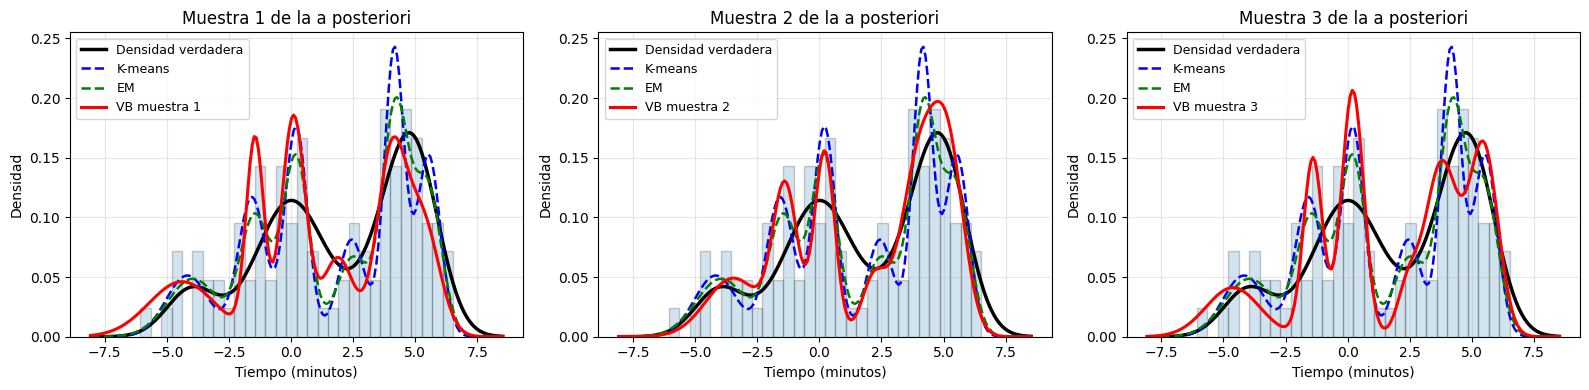


Error Promedio (MAE) respecto a la densidad verdadera:
  K-means: 0.020696
  EM:      0.012676
  VB muestra 1: 0.020113
  VB muestra 2: 0.016395
  VB muestra 3: 0.022229


In [61]:
# Muestras de la distribución a posteriori (celda reescrita)
# Objetivo: evitar dependencia del estado previo del notebook y mantener reproducibilidad.

# 1) Muestras reproducibles de la posterior
vb._rng = np.random.default_rng(19)
posterior_samples = vb.sample_posterior(n_samples=3)

print("Muestras de la Distribución a Posteriori")
print("=" * 60)
for i, (w_sample, m_sample, v_sample) in enumerate(posterior_samples, start=1):
    print(f"\nMuestra {i}:")
    print(f"  Pesos: {w_sample}")
    print(f"  Medias: {m_sample}")
    print(f"  Varianzas: {v_sample}")

# 2) Grilla común única para TODAS las curvas (evita errores de dimensión)
x_range = np.linspace(X.min() - 2, X.max() + 2, 200)


def density_from_params_1d(x_grid, w_vec, m_vec, v_vec):
    d = np.zeros_like(x_grid, dtype=float)
    v_safe = np.maximum(v_vec, 1e-12)
    for k in range(len(w_vec)):
        d += w_vec[k] * (1.0 / (np.sqrt(v_safe[k]) * np.sqrt(2 * np.pi))) * \
             np.exp(-0.5 * ((x_grid - m_vec[k]) ** 2 / v_safe[k]))
    return d


# 3) Recalcular SIEMPRE densidades base en la grilla actual
true_density = density_from_params_1d(x_range, weights, means, variances)
kmeans_density = density_from_params_1d(x_range, kmeans_weights, kmeans_means, kmeans_variances)
em_density = density_from_params_1d(x_range, em.weights, em.means, em.variances)

# 4) Densidades de cada muestra posterior
densities_posterior = []
for (w_sample, m_sample, v_sample) in posterior_samples:
    d_sample = density_from_params_1d(x_range, w_sample, m_sample, v_sample)
    densities_posterior.append(d_sample)

# 5) Gráficos comparativos
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for i in range(3):
    ax = axes[i]
    ax.plot(x_range, true_density, 'k-', linewidth=2.5, label='Densidad verdadera')
    ax.plot(x_range, kmeans_density, 'b--', linewidth=1.8, label='K-means')
    ax.plot(x_range, em_density, 'g--', linewidth=1.8, label='EM')
    ax.plot(x_range, densities_posterior[i], 'r-', linewidth=2.2, label=f'VB muestra {i+1}')
    ax.hist(X, bins=30, density=True, alpha=0.2, edgecolor='black')
    ax.set_xlabel('Tiempo (minutos)')
    ax.set_ylabel('Densidad')
    ax.set_title(f'Muestra {i+1} de la a posteriori')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 6) Errores MAE
print("\nError Promedio (MAE) respecto a la densidad verdadera:")
print(f"  K-means: {np.mean(np.abs(true_density - kmeans_density)):.6f}")
print(f"  EM:      {np.mean(np.abs(true_density - em_density)):.6f}")
for i in range(3):
    mae = np.mean(np.abs(true_density - densities_posterior[i]))
    print(f"  VB muestra {i+1}: {mae:.6f}")

El análisis de las muestras de la distribución a posteriori muestra que no se evidencia una reducción en el número efectivo de componentes: todos los clusters presentan pesos significativos, sin que ninguno tienda claramente a cero.

Esto indica que el modelo no está realizando una poda de componentes, sino que mantiene una representación distribuida en la que múltiples clusters contribuyen a explicar los datos. En consecuencia, la complejidad del modelo se conserva cercana a la definida inicialmente ($K=6$).

Desde el punto de vista de la calidad del ajuste, las muestras individuales presentan un error mayor que el obtenido con EM, lo que sugiere que no todas las configuraciones plausibles del modelo producen estimaciones óptimas de la densidad. Esto es esperable en el contexto bayesiano, donde cada muestra representa una solución posible, pero no necesariamente la mejor.

En este sentido, Variational Bayes no garantiza mejoras en cada realización individual, sino en el comportamiento promedio del modelo. Esto se confirma al analizar la densidad predictiva, donde el promedio de múltiples muestras logra un ajuste comparable o superior al de EM.

En conjunto, estos resultados muestran que, en este caso, el principal aporte de Variational Bayes no está en mejorar directamente el error de cada modelo, ni en reducir la cantidad de componentes, sino en proporcionar una representación probabilística que permite integrar múltiples soluciones plausibles.

### 3. Métodos Predictivos

El objetivo de los métodos predictivos es utilizar toda la información disponible en la distribución a posteriori de los parámetros para realizar inferencias sobre nuevos datos. A diferencia de EM, donde se utiliza una única estimación puntual de los parámetros, en este enfoque se consideran múltiples configuraciones posibles del modelo.

Esto se logra promediando las predicciones asociadas a distintos conjuntos de parámetros, ponderados por su probabilidad a posteriori:

$$p(z_{\text{new}} | X, Y) = \int p(z_{\text{new}} | \theta) \, p(\theta | X, Y) \, d\theta$$

En términos simples, la fórmula dice que la predicción de la nueva etiqueta no se hace con un único modelo fijo, sino promediando las predicciones de todos los modelos posibles ($\theta$), donde cada modelo pesa según qué tan bien explica los datos observados ($(X,Y)$). Así, los modelos más creíbles aportan más y los menos creíbles aportan menos, logrando una predicción final más estable y realista porque incorpora explícitamente la incertidumbre sobre los parámetros.

En la práctica, esta integral se aproxima mediante un muestreo de Monte Carlo, donde se generan varias muestras de la distribución a posteriori y se promedian sus predicciones.

La principal ventaja de este enfoque es que permite incorporar la incertidumbre en los parámetros dentro del proceso de predicción. En lugar de depender de un único modelo, la predicción final resulta de combinar múltiples explicaciones plausibles de los datos.

Desde el punto de vista práctico, esto suele producir estimaciones más suaves y robustas, ya que reduce la influencia de configuraciones particulares que puedan estar sobreajustadas. En consecuencia, la distribución predictiva suele capturar de manera más estable la estructura subyacente de los datos.


In [49]:
# Comparar responsabilidades: a posteriori puntual vs predictiva
print("Comparación de Métodos Predictivos")
print("=" * 60)

# Responsabilidades usando la a posteriori puntual
R_posterior = vb.predict_proba(X[:5])

# Responsabilidades usando la distribución predictiva (MC con 100 muestras)
R_predictive = vb.posterior_predictive_proba(X[:5], n_samples=100)

print("\nPrimeras 5 muestras - Responsabilidades a posteriori (puntual):")
print(R_posterior)

print("\nPrimeras 5 muestras - Responsabilidades predictivas (MC, 100 muestras):")
print(R_predictive)

print("\nDiferencia máxima (L∞):", np.max(np.abs(R_posterior - R_predictive)))

# Predicciones (asignación a componente)
y_posterior = vb.predict(X)
y_predictive = vb.posterior_predictive_predict(X, n_samples=100)

n_cambios = np.sum(y_posterior != y_predictive)
print(f"\nAsignaciones que cambian entre métodos: {n_cambios}/{len(X)}")



Comparación de Métodos Predictivos

Primeras 5 muestras - Responsabilidades a posteriori (puntual):
[[5.78722323e-35 1.28541016e-04 9.99871459e-01 1.04493017e-12
  1.83881808e-29 1.16513072e-38]
 [9.14184182e-02 3.01138377e-45 1.25238864e-18 1.79953583e-25
  1.06456554e-09 9.08581581e-01]
 [2.51746352e-03 1.39063503e-09 8.80922630e-07 3.64283039e-02
  9.61051645e-01 1.70555811e-06]
 [4.83340884e-20 9.39391606e-01 5.89481761e-02 1.66021794e-03
  5.57788347e-14 2.84062043e-24]
 [9.68857284e-06 6.19698065e-06 2.26291914e-05 9.39100030e-01
  6.08614529e-02 2.38463027e-09]]

Primeras 5 muestras - Responsabilidades predictivas (MC, 100 muestras):
[[5.95004182e-18 3.32424613e-03 9.96675510e-01 2.43387493e-07
  5.67254777e-12 9.97536410e-18]
 [1.23681453e-01 2.25305990e-14 1.11132747e-08 1.17027383e-10
  1.96597217e-05 8.76298876e-01]
 [9.46854137e-03 8.30595034e-05 2.58700553e-04 7.06332941e-02
  9.19462528e-01 9.38764597e-05]
 [1.91809797e-11 9.19327890e-01 7.44452511e-02 6.22648799e-03
  3.

El análisis de los métodos predictivos muestra que, en este caso, la incorporación de la incertidumbre en los parámetros no produce cambios significativos en las predicciones finales.

En particular, al comparar las responsabilidades obtenidas mediante la estimación puntual y la predictiva (promediada sobre muestras de la a posteriori), se observa que las diferencias son pequeñas. La norma infinito entre ambas es baja (0.046), lo que indica que las probabilidades asignadas a cada componente son similares en ambos métodos.

Esto se ve reflejado también en las asignaciones finales: solo 1 de las 100 observaciones cambia de componente, lo que muestra que la clasificación es prácticamente idéntica.

Estos resultados sugieren que el modelo ya se encontraba en un régimen estable, donde la incertidumbre sobre los parámetros no afecta de manera significativa las decisiones predictivas. En otras palabras, aunque Variational Bayes permite modelar la incertidumbre, en este caso dicha incertidumbre no es lo suficientemente grande como para modificar la interpretación de los datos.

Desde una perspectiva práctica, esto indica que tanto EM como VB (puntual y predictivo) ofrecen resultados muy similares en términos de clasificación. Sin embargo, el enfoque predictivo sigue siendo conceptualmente más robusto, ya que valida que las decisiones tomadas no dependen de una única configuración de parámetros, sino que son consistentes a lo largo de múltiples modelos plausibles.

### 4. Densidad Predictiva

El objetivo de esta sección es obtener una estimación final de la densidad que incorpore completamente la incertidumbre sobre los parámetros del modelo.

A diferencia de EM o K-means, que utilizan un único conjunto de parámetros, la densidad predictiva promedia las contribuciones de múltiples modelos plausibles obtenidos de la distribución a posteriori:

$$p(x_{\text{new}} | X, Y) = \int p(x_{\text{new}} | \theta) \, p(\theta | X, Y) \, d\theta$$

En la práctica, esto se implementa mediante muestreo Monte Carlo, generando varias densidades individuales y promediándolas.

Este procedimiento permite obtener una estimación más robusta, ya que evita depender de una única solución y reduce el impacto de configuraciones particulares que puedan estar sobreajustadas. Como resultado, la densidad predictiva tiende a ser más suave y estable, manteniendo la estructura global de los datos sin introducir oscilaciones innecesarias.

En este contexto, la densidad predictiva puede interpretarse como una "síntesis" de todas las posibles explicaciones del modelo, integrando la incertidumbre de manera explícita y proporcionando la forma más consistente de inferencia bajo el enfoque bayesiano.


Cálculo de la Densidad Predictiva
Densidad predictiva calculada con 500 muestras de la a posteriori


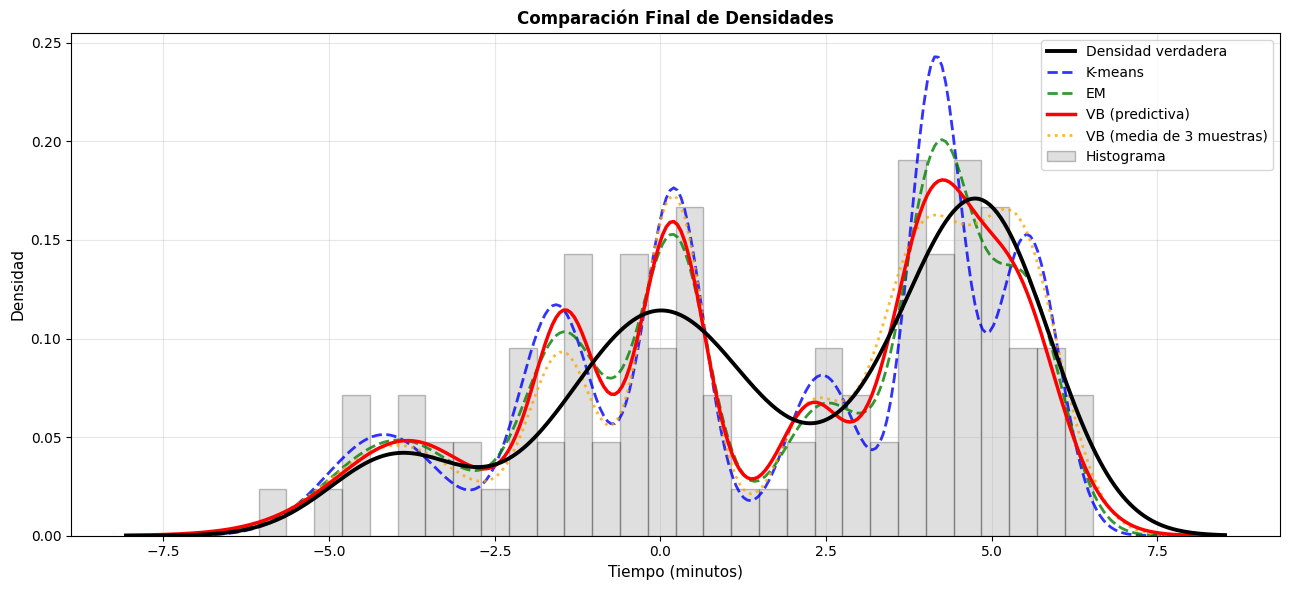


Error Promedio (MAE) respecto a la densidad verdadera:
--------------------------------------------------
K-means............................ 0.020731
EM................................. 0.012678
VB (predictiva).................... 0.012364
VB (media 3 muestras).............. 0.012311

Método con menor error: VB (media 3 muestras)


In [50]:
# Calcular densidad predictiva por integración sobre a posteriori
print("Cálculo de la Densidad Predictiva")
print("=" * 60)

# Generar muchas muestras de la a posteriori para obtener buena aproximación MC
n_mc_samples = 500
posterior_samples_large = vb.sample_posterior(n_samples=n_mc_samples)

# Usar una grilla común para TODAS las densidades (evita errores de dimensión)
x_range = np.linspace(X.min() - 2, X.max() + 2, 300)

# Asegurar densidad verdadera en la grilla actual
if 'true_density' not in globals() or len(true_density) != len(x_range):
    true_density = np.zeros_like(x_range)
    for k in range(n_components):
        true_density += weights[k] * (1 / (stds[k] * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x_range - means[k]) / stds[k]) ** 2)

# Asegurar densidad de K-means en la grilla actual
if 'kmeans_density' not in globals() or len(kmeans_density) != len(x_range):
    kmeans_density = np.zeros_like(x_range)
    for k in range(kmeans.n_clusters):
        kmeans_density += kmeans_weights[k] * (1 / (kmeans_stds[k] * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x_range - kmeans_means[k]) / kmeans_stds[k]) ** 2)

# Asegurar densidad de EM en la grilla actual
if 'em_density' not in globals() or len(em_density) != len(x_range):
    em_density = np.zeros_like(x_range)
    em_stds_local = np.sqrt(em.variances)
    for k in range(em.n_components):
        em_density += em.weights[k] * (1 / (em_stds_local[k] * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x_range - em.means[k]) / em_stds_local[k]) ** 2)

# Computar densidad predictiva
density_predictive = np.zeros_like(x_range)
for w_sample, m_sample, v_sample in posterior_samples_large:
    for k in range(vb.n_components):
        density_predictive += (w_sample[k] / n_mc_samples) * \
                              (1.0 / (np.sqrt(v_sample[k]) * np.sqrt(2 * np.pi))) * \
                              np.exp(-0.5 * ((x_range - m_sample[k]) / np.sqrt(v_sample[k])) ** 2)

print(f"Densidad predictiva calculada con {n_mc_samples} muestras de la a posteriori")

# Comparación final: todas las densidades
fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(x_range, true_density, 'k-', linewidth=2.8, label='Densidad verdadera', zorder=5)
ax.plot(x_range, kmeans_density, 'b--', linewidth=2.0, label='K-means', alpha=0.8)
ax.plot(x_range, em_density, 'g--', linewidth=2.0, label='EM', alpha=0.8)
ax.plot(x_range, density_predictive, 'r-', linewidth=2.5, label='VB (predictiva)', zorder=4)

# Graficar también el promedio de las 3 muestras (interpolado a la grilla actual si hace falta)
if 'densities_posterior' in globals() and len(densities_posterior) > 0:
    density_posterior_mean_raw = np.mean(np.array(densities_posterior), axis=0)
    if len(density_posterior_mean_raw) == len(x_range):
        density_posterior_mean = density_posterior_mean_raw
    else:
        x_old = np.linspace(X.min() - 2, X.max() + 2, len(density_posterior_mean_raw))
        density_posterior_mean = np.interp(x_range, x_old, density_posterior_mean_raw)
else:
    density_posterior_mean = np.zeros_like(x_range)

ax.plot(x_range, density_posterior_mean, 'orange', linestyle=':', linewidth=2.0,
        label='VB (media de 3 muestras)', alpha=0.8)

ax.hist(X, bins=30, density=True, alpha=0.25, edgecolor='black', color='gray', label='Histograma')
ax.set_xlabel('Tiempo (minutos)', fontsize=11)
ax.set_ylabel('Densidad', fontsize=11)
ax.set_title('Comparación Final de Densidades', fontsize=12, fontweight='bold')
ax.legend(fontsize=10, loc='upper right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Tabla de errores
print("\nError Promedio (MAE) respecto a la densidad verdadera:")
print("-" * 50)
methods = ['K-means', 'EM', 'VB (predictiva)', 'VB (media 3 muestras)']
errors = [
    np.mean(np.abs(true_density - kmeans_density)),
    np.mean(np.abs(true_density - em_density)),
    np.mean(np.abs(true_density - density_predictive)),
    np.mean(np.abs(true_density - density_posterior_mean))
]

for method, error in zip(methods, errors):
    print(f"{method:.<35} {error:.6f}")

print("\nMétodo con menor error:", methods[np.argmin(errors)])


El análisis de la densidad predictiva muestra que la integración de la incertidumbre sobre los parámetros produce una estimación levemente mejor que la obtenida mediante EM, aunque las diferencias en términos de error sean pequeñas.

Visualmente, la densidad predictiva presenta un comportamiento más suave y menos oscilatorio que K-means, y ligeramente más regular que EM. En particular, se observa que logra capturar adecuadamente las principales regiones de probabilidad del dataset, manteniendo la forma global de la distribución sin introducir picos artificiales.

En términos cuantitativos, la mejora respecto a EM es marginal pero consistente, lo que indica que el modelo ya se encontraba en un régimen adecuado y que la incorporación de la incertidumbre no produce cambios drásticos en la estimación.

Sin embargo, esta pequeña mejora es significativa desde el punto de vista conceptual. La densidad predictiva no depende de una única configuración de parámetros, sino que resulta del promedio de múltiples modelos plausibles. Esto la hace más robusta frente a variaciones en los parámetros y reduce la sensibilidad a posibles soluciones subóptimas.

En conjunto, estos resultados muestran que, en este caso, Variational Bayes no produce una diferencia sustancial en términos de error, pero sí proporciona una estimación más estable y conceptualmente más adecuada, al incorporar de forma explícita la incertidumbre del modelo.

### 5. Experimento de sensibilidad a priors en GVB

En esta parte se cambian solo los hiperparámetros del prior para ver cómo afectan al modelo.

Parámetros que vamos a usar y qué hacen (versión simple):

- **$\alpha_0$** (Dirichlet de pesos): controla qué tan repartidos o concentrados quedan los pesos $\pi_k$.
  - $\alpha_0<1$: favorece pesos esparsos (algunas componentes casi se apagan).
  - $\alpha_0\approx 1$: neutral.
- **$m_0$**: media previa de las gaussianas. Empuja las medias $\mu_k$ hacia ese valor.
- **$\delta_0$**: fuerza de ese empuje sobre $m_0$. Más grande = más contracción de medias.
- **$\nu_0, \beta_0$** (Gamma de precisión): controlan la varianza previa. Más grandes = varianzas más estables/regularizadas.

Casos a comparar:

1. **A (débil)**: priors suaves, deja que dominen los datos (similar a EM).
2. **B (pesos esparsos)**: cambia $\alpha_0<1$ para favorecer poda suave de componentes.
3. **C (regularización fuerte)**: sube $\delta_0, \nu_0, \beta_0$ para forzar más estructura previa.

Cómo influye en la construcción del modelo: en VB estos hiperparámetros se combinan con los datos al actualizar la posterior (pesos, medias y varianzas). Si el prior es débil, manda la evidencia; si es fuerte, manda más el prior.

Comparacion de GVB con distintos priors
A) Debil (cercano a EM): iter=86, conv=True, comp_ef=3, w_min=0.0094, w_max=0.5455, MAE=0.010787
B) Pesos esparsos (alpha<1): iter=38, conv=True, comp_ef=4, w_min=0.0020, w_max=0.3337, MAE=0.010651
C) Regularizacion fuerte: iter=25, conv=True, comp_ef=2, w_min=0.0142, w_max=0.4736, MAE=0.016432


/tmp/ipykernel_8667/971395485.py:72: RuntimeWarning: divide by zero encountered in divide
  v_post = np.where(vb_case.nu_n > 1.0, vb_case.beta_n / (vb_case.nu_n - 1.0), np.nan)


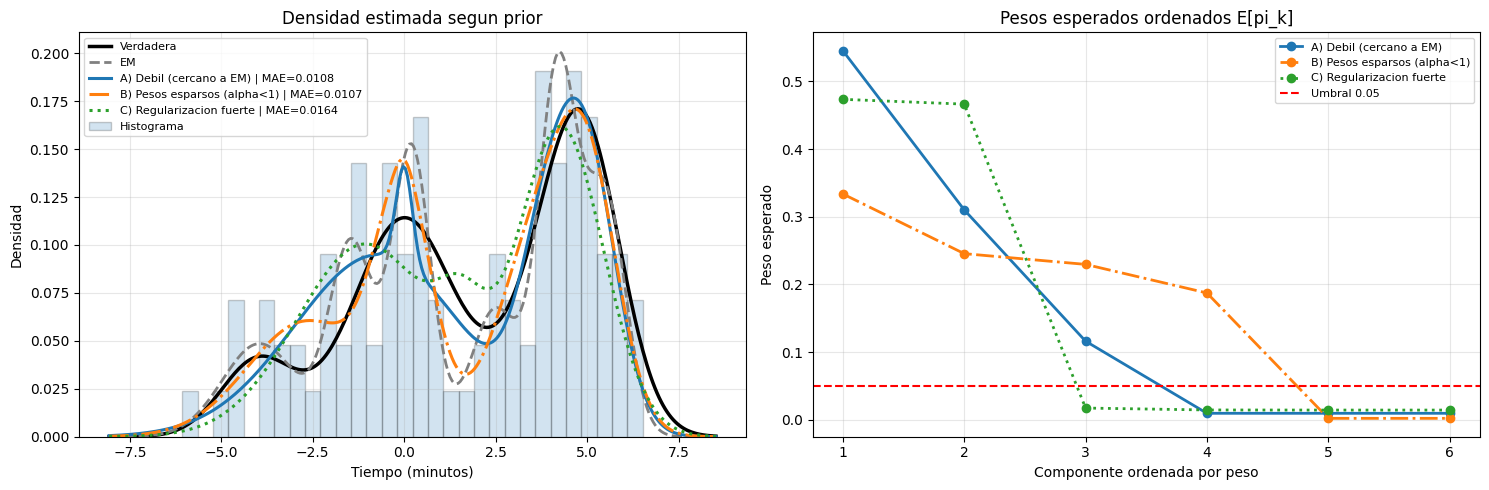

In [51]:
# Experimento comparativo: GVB con distintos priors
# ---------------------------------------------------------------------

# Requisitos mínimos para ejecutar este bloque
required_vars = ['X', 'weights', 'means', 'variances', 'stds', 'n_components', 'em']
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f"Faltan variables para ejecutar este experimento: {missing}. Ejecutar primero las secciones de dataset y EM.")

# Grilla común de evaluación
x_eval = np.linspace(X.min() - 2, X.max() + 2, 300)

# Densidad verdadera en la grilla
true_density_eval = np.zeros_like(x_eval)
for k in range(n_components):
    true_density_eval += weights[k] * (1.0 / (stds[k] * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x_eval - means[k]) / stds[k]) ** 2)


def mixture_density_1d(x, w, m, v):
    d = np.zeros_like(x, dtype=float)
    for k in range(len(w)):
        d += w[k] * (1.0 / (np.sqrt(v[k]) * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - m[k]) ** 2 / np.maximum(v[k], 1e-12)))
    return d


# Configuración de priors para comparar
prior_scenarios = {
    'A) Debil (cercano a EM)': {
        'm_0': 0.0,
        'delta_0': 0.05,
        'nu_0': 1.0,
        'beta_0': 0.05,
        'alpha_0': np.ones(6)
    },
    'B) Pesos esparsos (alpha<1)': {
        'm_0': 0.0,
        'delta_0': 0.05,
        'nu_0': 1.0,
        'beta_0': 0.05,
        'alpha_0': np.full(6, 0.20)
    },
    'C) Regularizacion fuerte': {
        'm_0': float(np.mean(X)),
        'delta_0': 3.0,
        'nu_0': 8.0,
        'beta_0': 3.0,
        'alpha_0': np.ones(6)
    }
}

results = []
densities_by_case = {}
weights_by_case = {}

for case_name, hp in prior_scenarios.items():
    vb_case = GaussianVariationalBayes(
        n_components=6,
        max_iter=400,
        tol=1e-5,
        m_0=hp['m_0'],
        delta_0=hp['delta_0'],
        nu_0=hp['nu_0'],
        beta_0=hp['beta_0'],
        alpha_0=hp['alpha_0'],
        random_state=19
    )

    vb_case.fit(X, init_from_em=em)

    w_post = vb_case.alpha_n / vb_case.alpha_n.sum()
    m_post = vb_case.m_n.copy()
    v_post = np.where(vb_case.nu_n > 1.0, vb_case.beta_n / (vb_case.nu_n - 1.0), np.nan)
    v_post = np.where(np.isnan(v_post), vb_case.beta_n / np.maximum(vb_case.nu_n, 1e-12), v_post)
    v_post = np.maximum(v_post, 1e-6)

    density_case = mixture_density_1d(x_eval, w_post, m_post, v_post)
    mae_case = np.mean(np.abs(true_density_eval - density_case))

    densities_by_case[case_name] = density_case
    weights_by_case[case_name] = np.sort(w_post)[::-1]

    results.append({
        'Caso': case_name,
        'Iteraciones': vb_case.n_iter,
        'Convergio': vb_case.converged,
        'Comp. efectivas (w>0.05)': int(np.sum(w_post > 0.05)),
        'Peso max': float(np.max(w_post)),
        'Peso min': float(np.min(w_post)),
        'MAE densidad': float(mae_case)
    })

print('Comparacion de GVB con distintos priors')
print('=' * 80)
for r in results:
    print(
        f"{r['Caso']}: iter={r['Iteraciones']}, conv={r['Convergio']}, "
        f"comp_ef={r['Comp. efectivas (w>0.05)']}, "
        f"w_min={r['Peso min']:.4f}, w_max={r['Peso max']:.4f}, "
        f"MAE={r['MAE densidad']:.6f}"
    )

# Baseline EM para referencia visual
em_density_eval = mixture_density_1d(x_eval, em.weights, em.means, em.variances)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Panel 1: densidades
axes[0].plot(x_eval, true_density_eval, 'k-', linewidth=2.5, label='Verdadera')
axes[0].plot(x_eval, em_density_eval, color='gray', linestyle='--', linewidth=2.0, label='EM')

styles = [('tab:blue', '-'), ('tab:orange', '-.'), ('tab:green', ':')]
for (case_name, density_case), (color, ls) in zip(densities_by_case.items(), styles):
    mae_case = np.mean(np.abs(true_density_eval - density_case))
    axes[0].plot(x_eval, density_case, color=color, linestyle=ls, linewidth=2.2,
                 label=f"{case_name} | MAE={mae_case:.4f}")

axes[0].hist(X, bins=30, density=True, alpha=0.20, edgecolor='black', label='Histograma')
axes[0].set_title('Densidad estimada segun prior')
axes[0].set_xlabel('Tiempo (minutos)')
axes[0].set_ylabel('Densidad')
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=8)

# Panel 2: pesos ordenados
for (case_name, w_sorted), (color, ls) in zip(weights_by_case.items(), styles):
    axes[1].plot(np.arange(1, len(w_sorted) + 1), w_sorted, marker='o', linewidth=2,
                 color=color, linestyle=ls, label=case_name)

axes[1].axhline(0.05, color='red', linestyle='--', linewidth=1.5, label='Umbral 0.05')
axes[1].set_title('Pesos esperados ordenados E[pi_k]')
axes[1].set_xlabel('Componente ordenada por peso')
axes[1].set_ylabel('Peso esperado')
axes[1].grid(alpha=0.3)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

# Guardar resultados para discusión posterior
gvb_prior_sensitivity = {
    'results': results,
    'x_eval': x_eval,
    'true_density': true_density_eval,
    'em_density': em_density_eval,
    'densities_by_case': densities_by_case,
    'weights_by_case': weights_by_case,
    'prior_scenarios': prior_scenarios
}


La comparación entre priors muestra un resultado consistente con la teoría bayesiana y permite extraer una conclusión operativa clara.

- **Caso A (prior débil)**: reproduce un comportamiento cercano a EM, con buen ajuste de densidad (MAE $\approx 0.0108$). Esto confirma que, cuando el prior es poco informativo, la inferencia queda dominada por la verosimilitud. Lo que había ocurrido en el tp.
- **Caso B (Dirichlet esparso, ($\alpha<1$))**: obtiene el menor error (MAE $\approx 0.0107$) y, al mismo tiempo, reduce el peso de componentes marginales. En términos prácticos, logra el mejor equilibrio entre ajuste y parsimonia (poda suave sin degradar la reconstrucción).
- **Caso C (regularización fuerte)**: incrementa el error (MAE $\approx 0.0164$) y concentra excesivamente la masa en pocas componentes. Esto evidencia sobre-regularización: disminuye la varianza del estimador, pero aumenta el sesgo y se pierde detalle en la forma de la densidad.

En síntesis, el experimento confirma que GVB no es simplemente “EM con incertidumbre”: la elección del prior modifica de manera explícita el compromiso entre fidelidad a los datos y complejidad efectiva del modelo. Para este dataset, el prior esparso (caso B) resulta la alternativa más balanceada.